Работу выполняла: Тагай Екатерина, 316 группа

# Технологический практикум. Первый этап

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
# устанавливаем библиотеки Python
import pip
pip.main(["install", "matplotlib"])
pip.main(["install", "scikit-learn"])
pip.main(["install", "scikit-image"])
pip.main(["install", "umap-learn"])
pip.main(["install", "pingouin"])
pip.main(["install", "hyperopt"])
pip.main(["install", "ipywidgets"])
pip.main(["install", "keras"])
pip.main(["install", "lightgbm"])
pip.main(["install", "numpy"])
pip.main(["install", "outlier_utils"])
pip.main(["install", "pandas"])
pip.main(["install", "plotly"])
pip.main(["install", "scipy"])
pip.main(["install", "seaborn"])
pip.main(["install", "scikit"])
pip.main(["install", "torch"])
pip.main(["install", "torchvision"])
!pip install --upgrade outlier_utils
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
import scipy
from scipy import stats
from statsmodels.stats.diagnostic import lilliefors
warnings.simplefilter("ignore")
%matplotlib inline
warnings.filterwarnings("ignore") #игнорируем предупреждающие сообщения


In [ ]:
%%R
# устанавливаем библиотеки R
oldw <- getOption("warn")
options(warn = -1)

install.packages("dplyr")
library(dplyr)
install.packages("Hmisc")
library(Hmisc)
install.packages("ggplot2")
install.packages("highcharter")
install.packages("Leaflet")
install.packages("RColorBrewer")
install.packages("Plotly")
install.packages("sunburstR")
install.packages("RGL")
install.packages("dygraphs")
install.packages("outliers")
library(outliers)
install.packages("mice")
library(mice)
install.packages("corrplot")
library(corrplot)
install.packages('car')
library(car)
nstall.packages("psych")
library(psych)
packages <- c('ggplot2', 'dplyr', 'tidyr', 'tibble')
library(tidyr)
library(tibble)

install.packages("nortest")
library(nortest)
install.packages("ggpubr")

# **Задание 1**

*Выбрать уникальные для каждого студента в группе датасеты для
выполнения заданий практикума. Подготовить их описание, краткие
характеристики (максимумы-минимумы, средние значения, пропуски и т.п.).*

Первый датасет **"Impact_on_agriculture_2024"** *рассматривает влияние разных факторов на производительность сельского хозяйства.* Он включает данные  **о урожайности** агрохозяйства, **стране/регионе**, в котором это сельскохозяйственное предприятие находится, **температуре**, **осадках**, **стратегии адаптации** и т.д. Я решила остановиться на рассмотрении одной из самых важных зерновых культур - **кукурузe.**

In [ ]:
df1= pd.read_csv("impact_on_agriculture_2024.csv")
df1 = df1[df1.Crop_Type == 'Corn']
df1.reset_index(inplace = True, drop=True)
df1

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2011,Brazil,Southeast,Corn,15.75,1433.31,11.91,2.080,6,79.20,25.19,67.56,55.03,Organic Farming,933.72
3,2011,USA,West,Corn,15.76,2317.59,21.33,3.807,0,94.85,47.02,35.76,48.60,Drought-resistant Crops,1627.44
4,2002,India,Punjab,Corn,9.97,2310.19,23.27,1.053,2,19.87,37.64,5.83,97.48,Water Management,285.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,1993,Australia,Queensland,Corn,0.22,1677.08,18.61,1.953,4,49.39,2.28,6.64,35.59,No Adaptation,784.11
1018,1994,Russia,Siberian,Corn,19.47,1352.23,6.40,4.060,9,95.35,11.25,99.29,60.50,Crop Rotation,1892.18
1019,2005,Argentina,Patagonia,Corn,14.96,2858.46,3.99,4.560,0,28.68,4.71,40.82,74.12,Crop Rotation,1029.27
1020,2015,Brazil,South,Corn,33.02,293.46,18.22,3.051,8,78.94,9.36,84.02,76.51,Crop Rotation,510.45


In [ ]:
df11 = df1[[ 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA',
            'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index',
            'Adaptation_Strategies', 'Economic_Impact_Million_USD']]
df11

,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,14.54,10.08,14.78,83.25,Water Management,808.13
1,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,79.20,25.19,67.56,55.03,Organic Farming,933.72
3,94.85,47.02,35.76,48.60,Drought-resistant Crops,1627.44
4,19.87,37.64,5.83,97.48,Water Management,285.96
...,...,...,...,...,...,...
1017,49.39,2.28,6.64,35.59,No Adaptation,784.11
1018,95.35,11.25,99.29,60.50,Crop Rotation,1892.18
1019,28.68,4.71,40.82,74.12,Crop Rotation,1029.27
1020,78.94,9.36,84.02,76.51,Crop Rotation,510.45


In [ ]:
df1.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,1022.000000,1022.000000,1022.000000,1022.000000,1022.00000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000
mean,2007.027397,15.296800,1631.928728,15.172221,2.22317,4.944227,55.352955,24.879217,50.193102,64.400519,666.718258
std,10.018652,11.294121,815.305633,8.626422,0.98000,3.190311,26.053741,14.386490,28.740604,20.443000,399.238631
min,1990.000000,-4.980000,200.170000,0.530000,0.47700,0.000000,10.160000,0.070000,0.080000,30.100000,53.760000
25%,1999.000000,5.745000,919.295000,7.735000,1.42400,2.000000,33.245000,12.317500,25.240000,46.212500,364.795000
50%,2006.000000,15.035000,1662.585000,14.825000,2.15050,5.000000,54.395000,24.635000,49.435000,63.750000,587.735000
75%,2016.000000,25.092500,2326.207500,22.905000,2.90000,8.000000,77.792500,37.107500,75.832500,82.095000,870.537500
max,2024.000000,34.920000,2998.880000,29.990000,4.99000,10.000000,99.940000,49.780000,99.910000,99.880000,2217.780000


In [ ]:
%%R
df1r <- read.csv(file = "impact_on_agriculture_2024.csv", header = TRUE)
df1r <- df1r[df1r$Crop_Type == "Corn",]
rownames(df1r) <- 0:(nrow(df1r) - 1)
dim(df1r)

[1] 1022   15


In [ ]:
%%R
describe(df1r)

df1r 

 15  Variables      1022  Observations
--------------------------------------------------------------------------------
Year 
       n  missing distinct     Info     Mean  pMedian      Gmd      .05 
    1022        0       35    0.999     2007     2007    11.56     1991 
     .10      .25      .50      .75      .90      .95 
    1994     1999     2006     2016     2021     2023 

lowest : 1990 1991 1992 1993 1994, highest: 2020 2021 2022 2023 2024
--------------------------------------------------------------------------------
Country 
       n  missing distinct 
    1022        0       10 
                                                                      
Value      Argentina Australia    Brazil    Canada     China    France
Frequency        107       113       111        99        93        87
Proportion     0.105     0.111     0.109     0.097     0.091     0.085
                                                  
Value          India   Nigeria    Russia       USA
Frequency

# **Задание 2**

*Реализовать аппроксимацию распределений данных с помощью ядерных оценок.*


Рассмотрим  распределение урожайности кукурузы (количество тонн урожая с одного гектара) в мире.

Text(0.5, 1.0, 'Распределение урожайности кукурузы в мире')

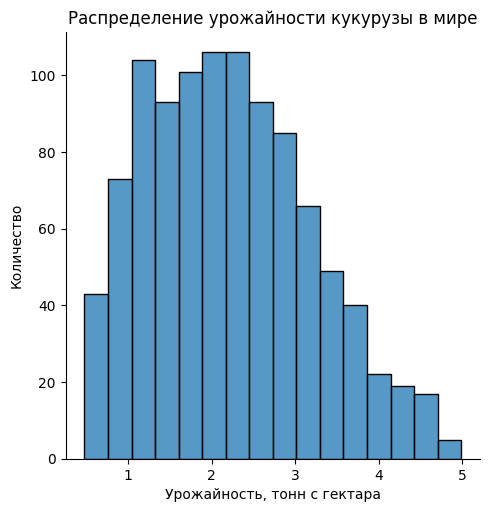

In [ ]:
sns.displot(x = 'Crop_Yield_MT_per_HA', data = df1)
plt.xlabel('Урожайность, тонн с гектара')
plt.ylabel('Количество')
plt.title('Распределение урожайности кукурузы в мире')

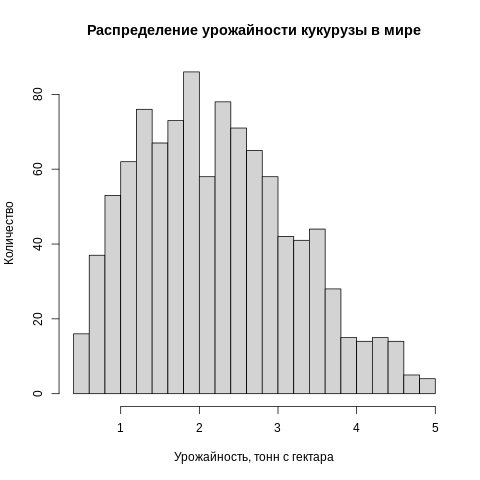

In [ ]:
%%R
hist(df1r$Crop_Yield_MT_per_HA,
     breaks =  20,
     xlab = "Урожайность, тонн с гектара",
     ylab = "Количество",
     main = "Распределение урожайности кукурузы в мире")

По графику видно, что данные, предоставленные нам, содержат в себе информацию о таких агрохозяйствах, где с одного гектара чаще всего получается собрать около 2-2.4 тонны кукурузы.

Рассмотрим, есть ли корреляция между страной и урожайностью в ней. Для этого построим гистограмму распределения урожайности для разных стран.

Text(24.70920833333333, 0.5, 'Количество')

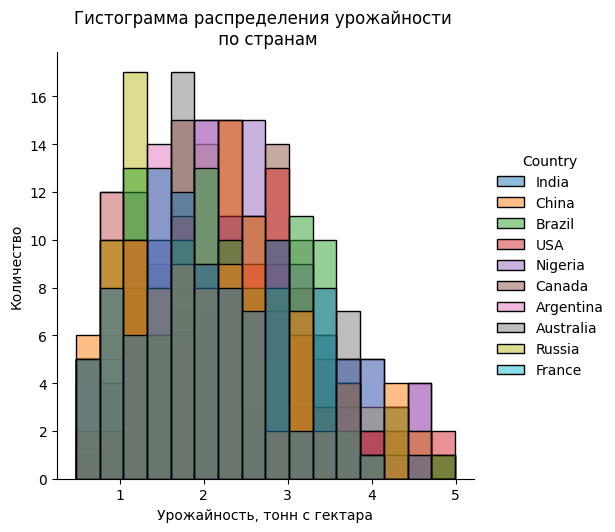

In [ ]:
sns.displot(x = 'Crop_Yield_MT_per_HA', hue = 'Country', data = df1)
plt.title('Гистограмма распределения урожайности \n по странам')
plt.xlabel('Урожайность, тонн с гектара')
plt.ylabel('Количество')

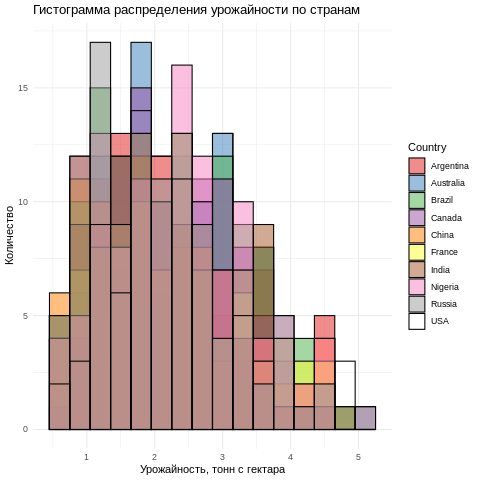

In [ ]:
%%R
ggplot(df1r, aes(x = Crop_Yield_MT_per_HA, fill = Country)) +
  geom_histogram(alpha = 0.5, binwidth = 0.3, color = "black", position = "identity") +
  labs(title = "Гистограмма распределения урожайности по странам",
       x = "Урожайность, тонн с гектара",
       y = "Количество") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set1")

Далее проаппроксимируем распределение урожайности по каждой стране по отдельности. Для этого воспользуемся методом ядерной оценки плотности. Это можно сделать с помощью функции displot, сделав значение параметра kde равным TRUE.

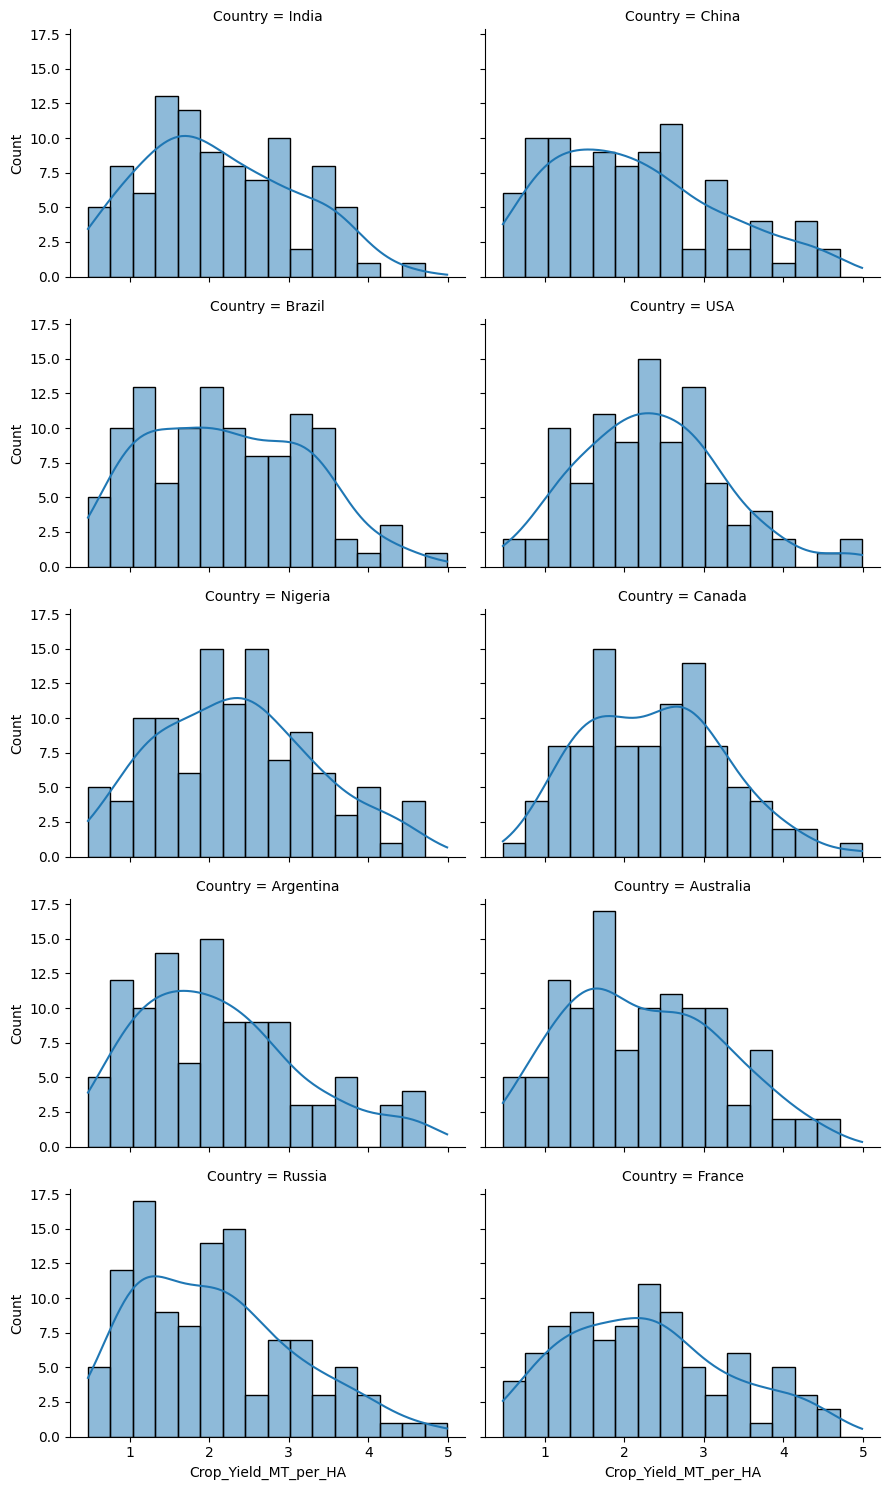

In [ ]:
sns.displot(x='Crop_Yield_MT_per_HA',  col='Country', kde=True, data=df1, height=3,  aspect=1.5,  col_wrap=2)

Для наглядности поместим все полученные графики на одну систему координат.

Text(2.959208333333331, 0.5, '')

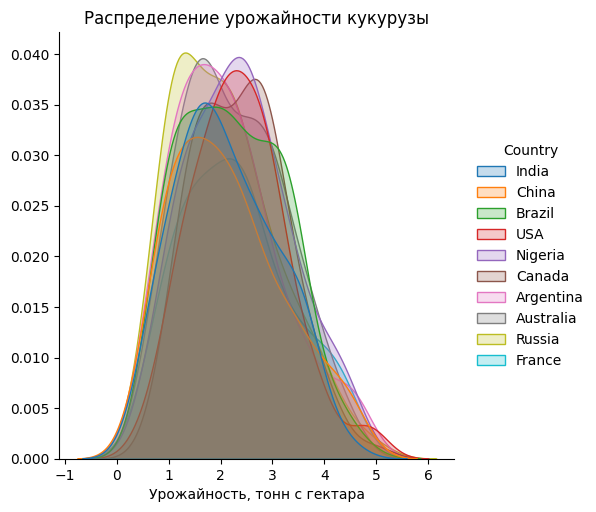

In [ ]:
sns.displot(x = "Crop_Yield_MT_per_HA", hue = "Country", kind = "kde", fill = True, data = df1)
plt.title('Распределение урожайности кукурузы')
plt.xlabel('Урожайность, тонн с гектара')
plt.ylabel('')

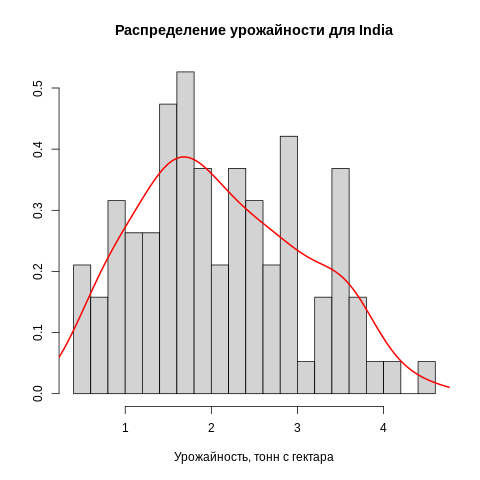

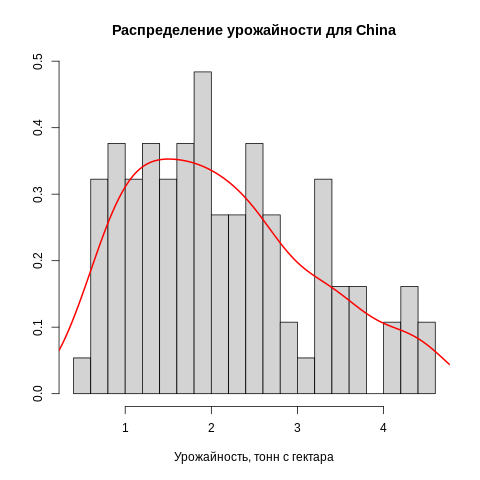

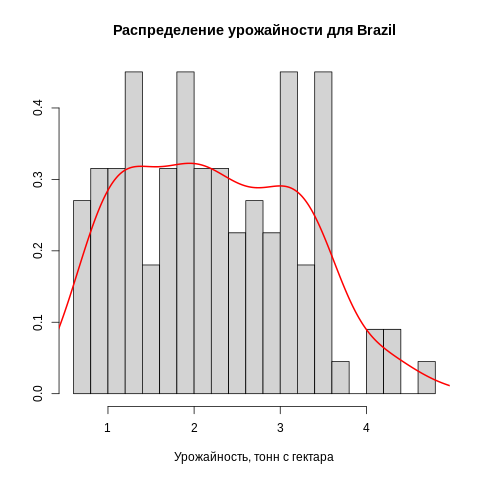

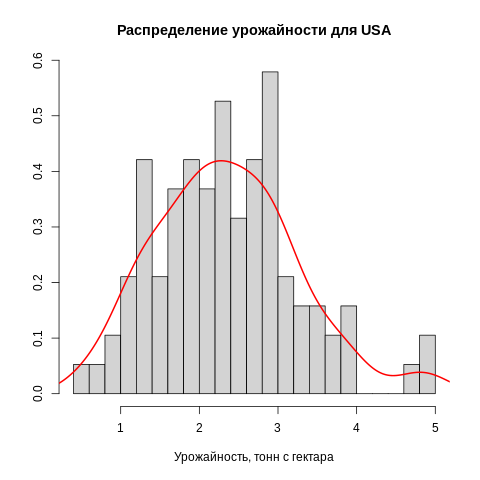

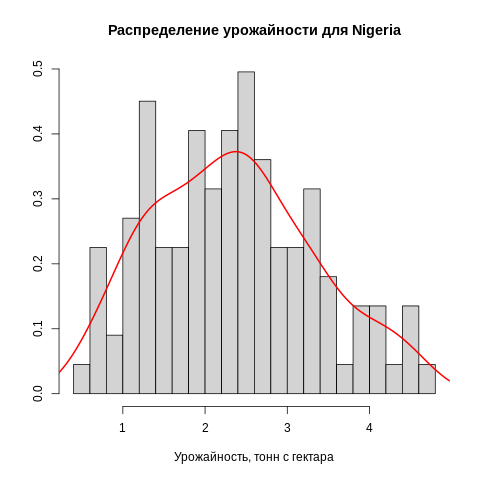

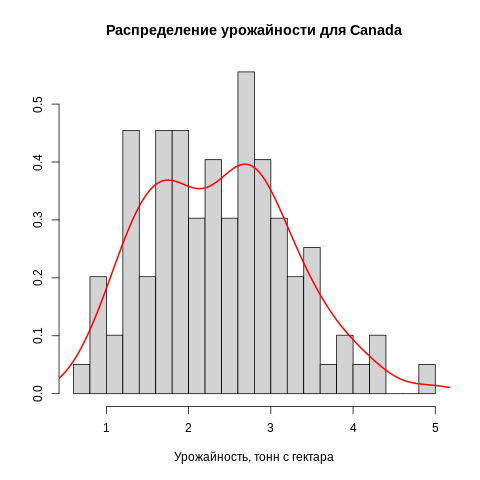

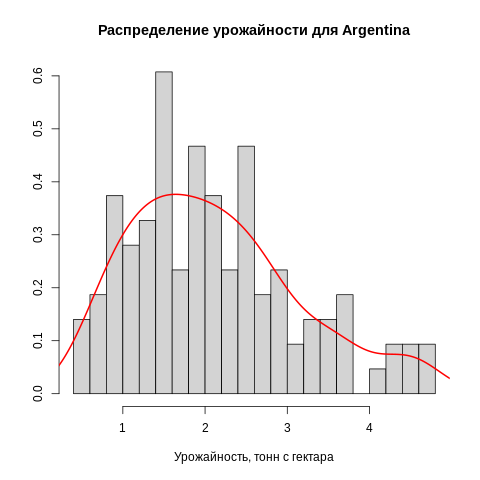

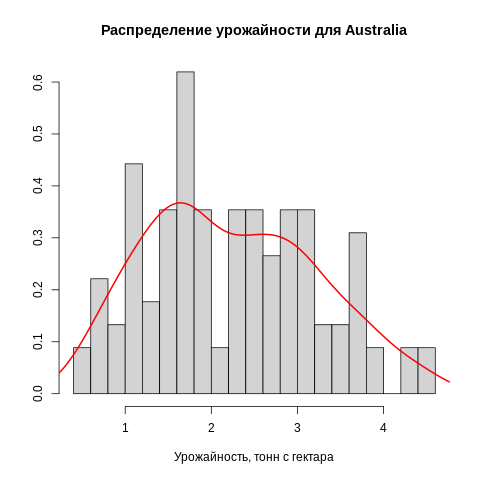

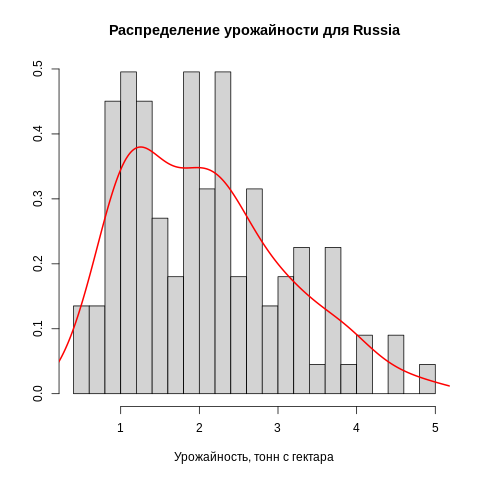

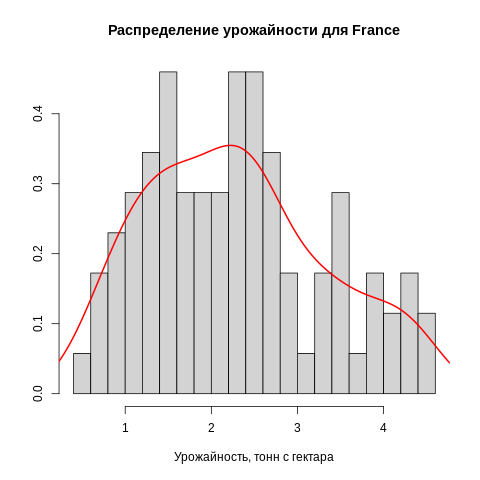

In [ ]:
%%R
countries <- unique(df1r$Country)
for (country in countries) {
  c_data <- df1r[df1r$Country == country, "Crop_Yield_MT_per_HA"]

  hist(c_data, freq = FALSE, breaks = 20, xlab = "Урожайность, тонн с гектара", ylab = "",
       main = paste("Распределение урожайности для", country))
  lines(density(c_data), col = "red", lwd = 2)
}

По всем приведенным выше графикам можно сделать вывод, что наиболее стабильная и высокая урожайность кукурузы выделяется в США и Канаде.

# **Задание 3**

*Реализовать анализ данных с помощью cdplot, dotchart, boxplot и
stripchart.*



**cdplot:**

cdplot — это функция в R, c помощью которой вычисляютс и строятся графики условной плотности, описывающие, как условное распределение категориальной переменной y меняется в зависимости от числовой переменной x. В языке Python аналогом данной функции может служить функция sns.displot с параметром multiple = "fill".

Рассмотрим распределение урожайности по стратегиям адапаиации.

Text(29.64012499999999, 0.5, 'Плотность')

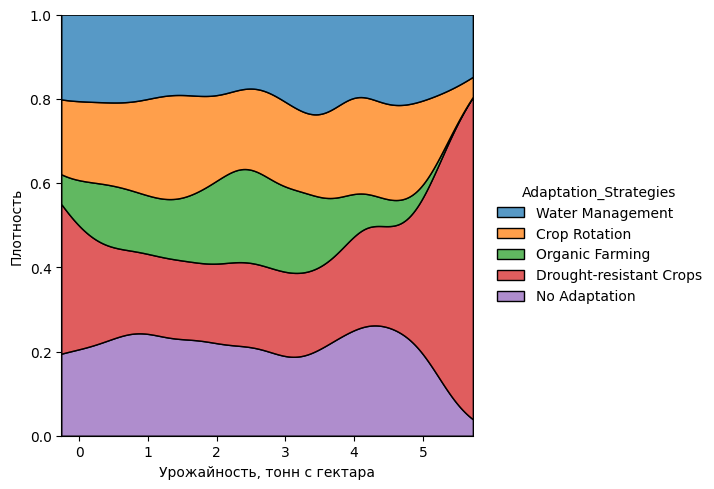

In [ ]:
sns.displot(df1, hue = "Adaptation_Strategies", multiple = "fill", x = "Crop_Yield_MT_per_HA", kind = "kde")
plt.xlabel('Урожайность, тонн с гектара')
plt.ylabel('Плотность')

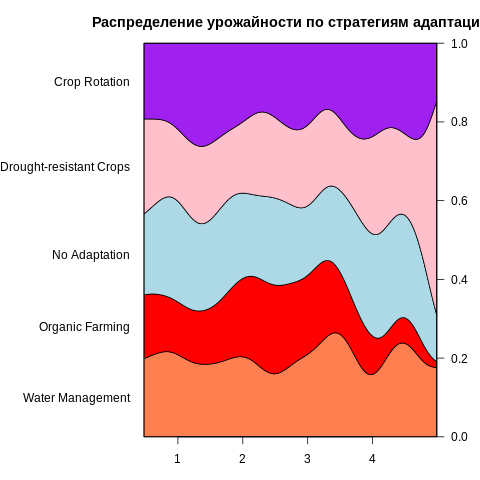

In [ ]:
%%R

df1r$Adaptation_Strategies <- as.factor(df1r$Adaptation_Strategies)
par(mar=c(3, 10, 3, 3), xpd=TRUE)
# Установка ориентации текста на оси Y
par(las=1)  # las=1 означает горизонтальное расположение текста

cdplot(Adaptation_Strategies ~ Crop_Yield_MT_per_HA, data = df1r, xlab = "Урожайность, тонн с гектара", col = c("coral", "red", "lightblue", "pink", "purple"), ylab = "",
       main = "Распределение урожайности по стратегиям адаптации")

На основании графика можно заключить, что управление водными ресурсами и использование устойчивых к засухе культур являются наиболее эффективными стратегиями адаптации для достижения высокой урожайности кукурузы.

**dotchart:**

dotchart — это функция в системе R, которая используется для построения точечных диаграмм Кливленда. Аналогом в языке Python может служить функция sns.scatterplot().


Text(0.5, 1.0, 'График зависимости урожайности кукурузы\n  в России от средней температуры ')

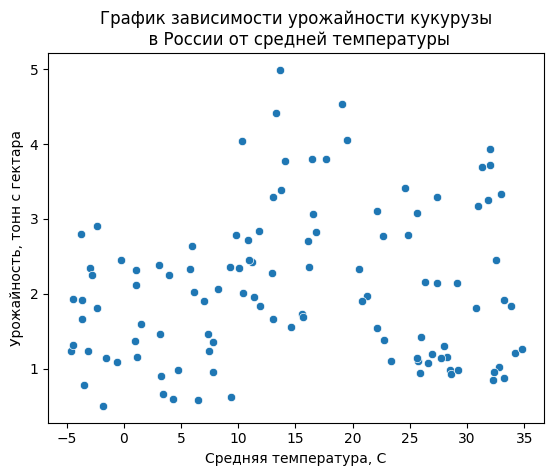

In [ ]:
sns.scatterplot(data=df1[df1['Country']=='Russia'], x="Average_Temperature_C", y="Crop_Yield_MT_per_HA")
plt.xlabel('Средняя температура, С')
plt.ylabel('Урожайность, тонн с гектара')
plt.title('График зависимости урожайности кукурузы\n  в России от средней температуры')

В данном случае мы рассмотрим урожайность кукурузы не во всем мире, а только в России. По графику можно сделать вывод, что оптимальная температура для выращивания кукурузы в России  - 12–20 °С. При температуре ниже 10 °С урожайность значительно падает и достигает минимальных значений. При температуре выше 25 °С урожайность может достигать высоких значений, но это случается реже, чем при 12–20 °С.

Text(0.5, 1.0, 'График зависимости урожайности кукурузы\n  в России от  количества осадков')

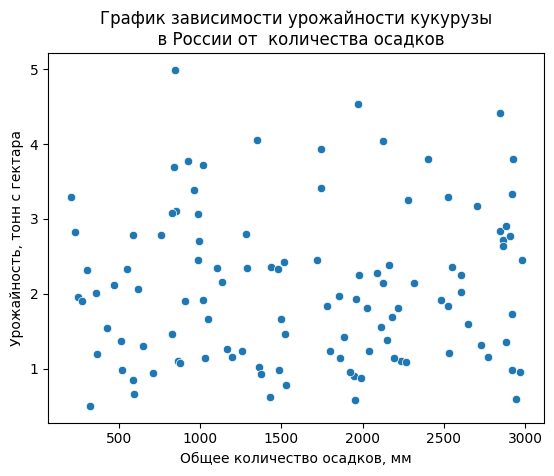

In [ ]:
sns.scatterplot(data=df1[df1['Country']=='Russia'], x="Total_Precipitation_mm", y="Crop_Yield_MT_per_HA")
plt.xlabel('Общее количество осадков, мм')
plt.ylabel('Урожайность, тонн с гектара')
plt.title('График зависимости урожайности кукурузы\n  в России от  количества осадков')

Урожайность кукурузы в России не имеет очевидной зависимости от общего количества осадков. Значит, на урожайность влияют другие факторы

Теперь построим график dotchart с помощью **языка R**.

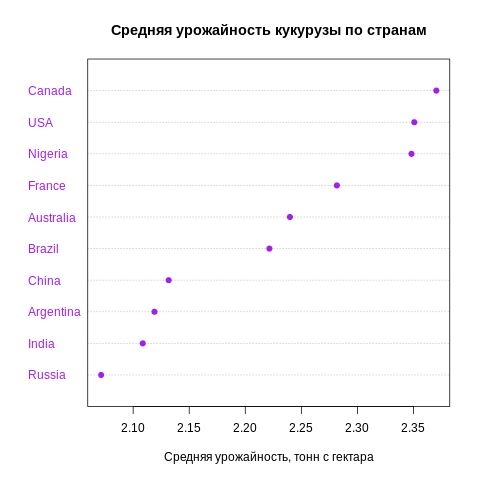

In [ ]:
%%R
df1r_avg_yield <- df1r %>%
  group_by(Country) %>%
  summarise(Average_Yield = mean(Crop_Yield_MT_per_HA, na.rm = TRUE)) %>%
  arrange(Average_Yield)
dotchart(df1r_avg_yield$Average_Yield,
         labels = df1r_avg_yield$Country,
         xlab = "Средняя урожайность, тонн с гектара",
         main = "Средняя урожайность кукурузы по странам",
         pch = 19,  # Залитые точки
         col = "purple")  # Синий цвет точек

Страны Канада, США, и Нигерия демонстрируют наибольшую урожайность среди стран на графике, превышающую 2.3 тонны с гектара.

**boxplot:**

boxplot - способ визуализации данных, предоставляющий компактное изображение пяти основных статистических показателей: минимума, первого квартиля, медианы, третьего квартиля и максимума, а также помогающий идентифицировать выбросы. В языке Python для создания boxplot можно воспользоваться функцией sns.boxplot().

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.

Text(0.5, 0, 'Уровень экстремальных погодных событий')

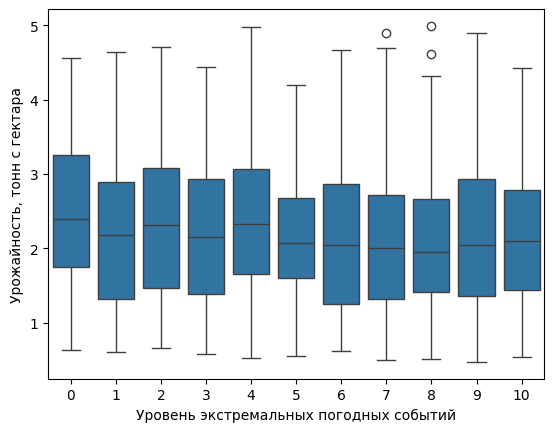

In [ ]:
sns.boxplot(data=df1, x='Extreme_Weather_Events', y = 'Crop_Yield_MT_per_HA')
plt.ylabel('Урожайность, тонн с гектара')
plt.xlabel('Уровень экстремальных погодных событий')

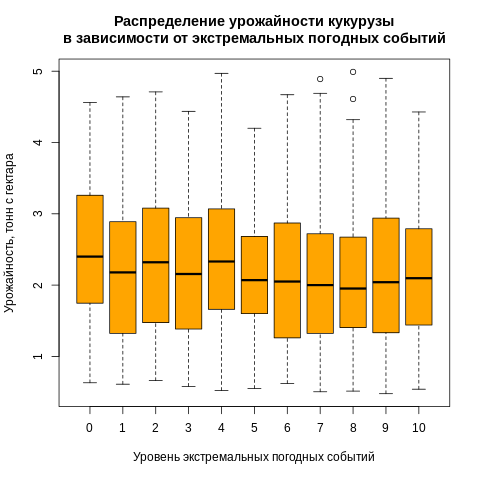

In [ ]:
%%R
boxplot(df1r$Crop_Yield_MT_per_HA ~ df1r$Extreme_Weather_Events,
        xlab = "Уровень экстремальных погодных событий",  # Подпись оси X
        ylab = "Урожайность, тонн с гектара",  # Подпись оси Y
        main = "Распределение урожайности кукурузы\nв зависимости от экстремальных погодных событий",  # Заголовок
        col = "orange",  # Цвет боксов
        horizontal = FALSE)  # Вертикальный boxplot

 В целом, влияние экстремальных погодных событий на урожайность кукурузы несущественно, так как медиана урожайности остается стабильной около 2–2,5 тонн на гектар, независимо от уровня случившихся экстремальных событий.
Однако, на уровнях 0 и 2 наблюдается более высокая медиана урожайности, что указывает на более благоприятные условия для кукурузы.

**stripchart:**

stripchart — это способ визуализации данных, который представляет собой распределение значений вдоль одной оси. Он позволяет отображать каждую точку данных отдельно, что помогает выявить плотность распределения и концентрацию значений в определённых диапазонах. В языке Python данная визуализация данных реализовывается с помощью функции sns.stripplot().


Text(0, 0.5, 'Страна')

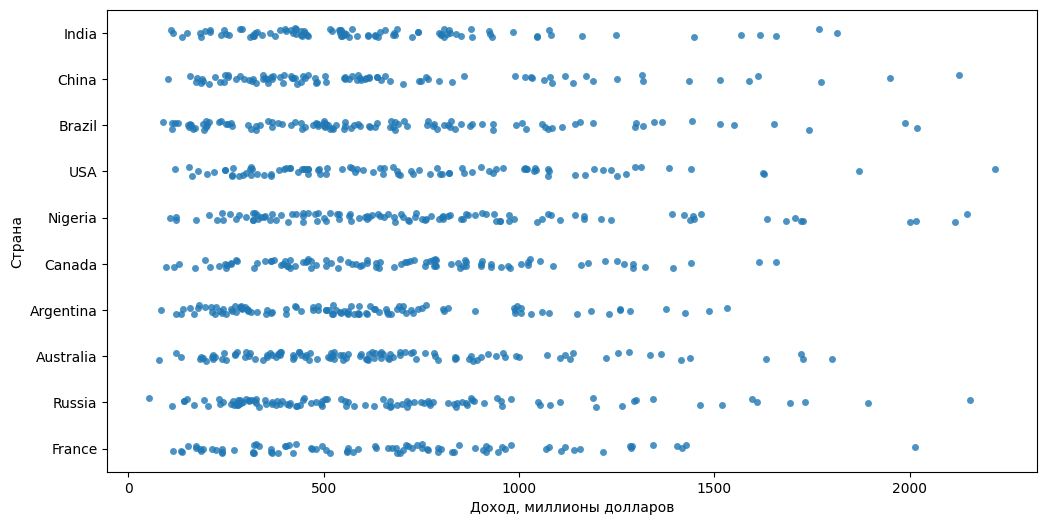

In [ ]:
plt.figure(figsize=(12, 6))
sns.stripplot(data = df1, y = 'Country', x = 'Economic_Impact_Million_USD', alpha = 0.8)
plt.xlabel('Доход, миллионы долларов')
plt.ylabel('Страна')

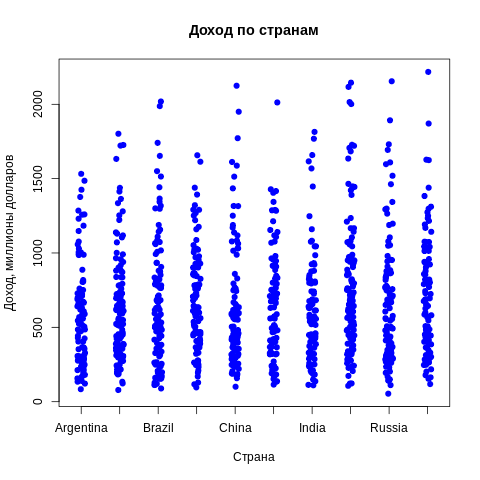

In [ ]:
%%R
stripchart(df1r$Economic_Impact_Million_USD ~ df1r$Country,
           method = "jitter",  # Добавляет "дрожание" для точек, чтобы избежать наложения
           vertical = TRUE,  # Вертикальный график
           pch = 19,  # Тип точки (заполненные кружки)
           col = "blue",  # Цвет точек
           xlab = "Страна",  # Подпись оси X
           ylab = "Доход, миллионы долларов",  # Подпись оси Y
           main = "Доход по странам")  # Заголовок

Для всех стран большая часть доходов сосредоточена в диапазоне до 1000 миллионов долларов.  Однако при этом значительная часть доходов США находится выше 1000 миллионов долларов и имеет самый высокий выброс (свыше 2000 млн долларов), что указывает на наиболее высокий уровень доходов по сравнению с другими странами. Также такие страны, как Бразилия, Нигерия, Канада, Россия, демонстрируют достаточно высокие доходы от агрохозяйств по сравнению с другими странами.

# **Задание 4**

 *Проверить, являются ли наблюдения выбросами с точки зрения
формальных статистических критериев Граббса и Q-теста Диксона.
Визуализировать результаты*.


Для определения выбросов используются критерий Граббса и Q-тест Диксона.

Сформулируем 2 гипотезы:

H0: Подозрительное значение не является выбросом.

H1: Подозрительное значение - выброс.


 **Критерий Граббса.** Более наглядно рассмотрим выбросы в колонке ‘Economic_Impact_Million_USD’, которые были замечены в предыдущем задании.

In [ ]:
from outliers import smirnov_grubbs as gr

outliers_indices = gr.max_test_indices(df1['Economic_Impact_Million_USD'])
outliers = df1.Economic_Impact_Million_USD.iloc[outliers_indices]
print(outliers)

106    2217.78
70     2154.93
13     2145.28
Name: Economic_Impact_Million_USD, dtype: float64


По полученным данным можно сказать, что самые высокие доходы от выращивания кукурузы были получены в таких странах, как США, Россия и Нигерия. Что очевидно, при этом в данных странах была достигнута высокая урожайность (более 4.5 тонн с гектара). Также можно обратить внимание, что в этих случаях общее количество осадков было выше среднего,  была высокая доступность к орошению/ ирригации (выше 60%) и в двух из трех случаев использовалась стратегия устойчивых к засухе культур.

In [ ]:
print("Номера строк с выбросами по осадкам: ", gr.max_test_indices(df1['Total_Precipitation_mm']))
print("Номера строк с выбросами по температуре: ", gr.max_test_indices(df1['Average_Temperature_C']))
print("Номера строк с выбросами по выделению СO2: ", gr.max_test_indices(df1['CO2_Emissions_MT']))
print("Номера строк с выбросами по использованию пестицидов : ",gr.max_test_indices(df1['Pesticide_Use_KG_per_HA']) )
print("Остальные выбросы:", gr.max_test_indices(df1['Fertilizer_Use_KG_per_HA']), gr.max_test_indices(df1['Soil_Health_Index']), gr.max_test_indices(df1['Crop_Yield_MT_per_HA']))

Номера строк с выбросами по осадкам:  []
Номера строк с выбросами по температуре:  []
Номера строк с выбросами по выделению СO2:  []
Номера строк с выбросами по использованию пестицидов :  []
Остальные выбросы: [] [] []


Проводя анализ дальше, я заметила, что по другим признакам выбросов нет.

Теперь реализуем тест Граббса на языке R.

In [ ]:
%%R
ans <- grubbs.test(df1r[]$Economic_Impact_Million_USD)
print(ans)
if (ans$p.value < 0.05) print('Данное значение - выброс.')
else print('Данное значение - не выброс.')


	Grubbs test for one outlier

data:  df1r[]$Economic_Impact_Million_USD
G = 3.8850, U = 0.9852, p-value = 0.04944
alternative hypothesis: highest value 2217.78 is an outlier

[1] "Данное значение - выброс."


In [ ]:
%%R
df1r[df1r$Economic_Impact_Million_USD == 2217.78, ]

    Year Country Region Crop_Type Average_Temperature_C Total_Precipitation_mm
106 2008     USA   West      Corn                 10.81                2083.43
    CO2_Emissions_MT Crop_Yield_MT_per_HA Extreme_Weather_Events
106             7.77                  4.9                      9
    Irrigation_Access_. Pesticide_Use_KG_per_HA Fertilizer_Use_KG_per_HA
106               63.54                   16.32                    93.93
    Soil_Health_Index   Adaptation_Strategies Economic_Impact_Million_USD
106             62.66 Drought-resistant Crops                     2217.78


Здесь тест Грабса нашел только один выброс со значением 2217.78 (строка 106).

**Q-тест Диксона.** Данный метод применим для малых выборок (не более 30 наблюдений). Поэтому, используя предыдущие выводы, обозначим два диапазона для поиска выбросов. В одном диапазоне выброс будет (диапазон [0:30]), в другом нет (диапазон [0:30]).  

Так как в Питоне нет реализации теста Диксона, то самостоятельно. Для этого возьмем выборку из 30 наблюдений при доверительной вероятности 0.9, тогда критическое значение равно 0.22.

In [ ]:
def dixon_test(d):
  out = []
  maX = max(d)
  second_max = max(d[d != maX])
  miN = min(d)
  max_q = (maX - second_max) / (maX - miN)
  if (max_q >= 0.22):
    out.append(maX)
  if out != []:
    print("Выброс в заданном диапазоне обнаружен: строка №",d[d.isin(out)])
  else:
    print("Выброс в заданном диапазоне не обнаружен.")

df_range1 = df1[0:30].Economic_Impact_Million_USD
df_range2 = df1[31:60].Economic_Impact_Million_USD
print('\tДиапазон [0:30]')
dixon_test(df_range1)
print('\tДиапазон [31:60]')
dixon_test(df_range2)

	Диапазон [0:30]
Выброс в заданном диапазоне обнаружен: строка № 13    2145.28
Name: Economic_Impact_Million_USD, dtype: float64
	Диапазон [31:60]
Выброс в заданном диапазоне не обнаружен.


Теперь реализуем Q-теста на языке R.

In [ ]:
%%R
ans1 <- dixon.test(df1r$Economic_Impact_Million_USD[0:30])
ans2 <- dixon.test(df1r$Economic_Impact_Million_USD[31:60])
print(ans1)
if (ans1$p.value < 0.05) print('Диапазон [0:30]. Полученное значение - выброс.')
else print('Диапазон [0:30]. Полученное значение - не выброс.')
print(ans2)
if (ans2$p.value < 0.05) print('Диапазон [31:60]. Полученное значение - выброс.')
else print('Диапазон [31:60]. Полученное значение - не выброс.')


	Dixon test for outliers

data:  df1r$Economic_Impact_Million_USD[0:30]
Q = 0.44313, p-value = 0.02727
alternative hypothesis: highest value 2145.28 is an outlier

[1] "Диапазон [0:30]. Полученное значение - выброс."

	Dixon test for outliers

data:  df1r$Economic_Impact_Million_USD[31:60]
Q = 0.18913, p-value = 0.9335
alternative hypothesis: highest value 1727.81 is an outlier

[1] "Диапазон [31:60]. Полученное значение - не выброс."


Результаты критерия Граббса и  q-теста в заданных диапозонах совпали.


Text(0.5, 0, 'Доход, миллионы долларов')

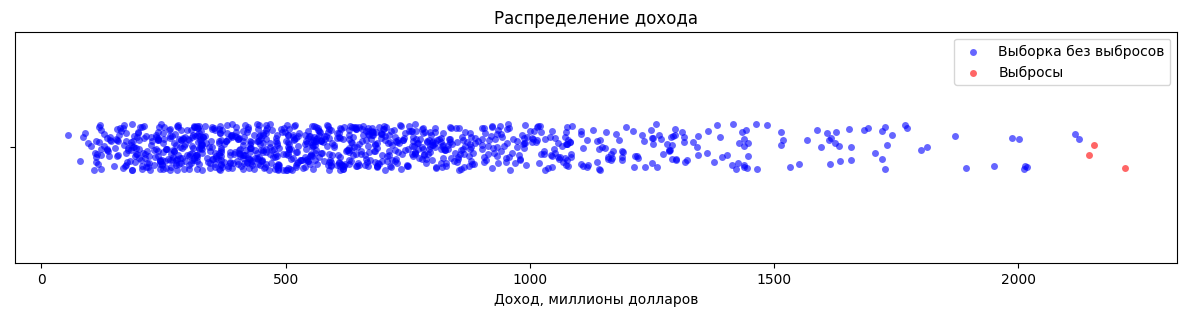

In [ ]:
plt.figure(figsize=(15, 3))
sns.stripplot(x=df1.Economic_Impact_Million_USD.drop(index=outliers_indices), color='blue', alpha=0.6, label='Выборка без выбросов')
sns.stripplot(x = df1.Economic_Impact_Million_USD.iloc[outliers_indices],color = 'red', alpha = 0.6, label = 'Выбросы' )
plt.title('Распределение дохода')
plt.xlabel('Доход, миллионы долларов')

# **Задание 5**

*Воспользоваться инструментами для заполнения пропусков в
данных. Пропуски внести вручную и сравнить результаты заполнения с
истинными значениями.*


Text(0.5, 1.0, 'График зависимости дохода\n от урожайность')

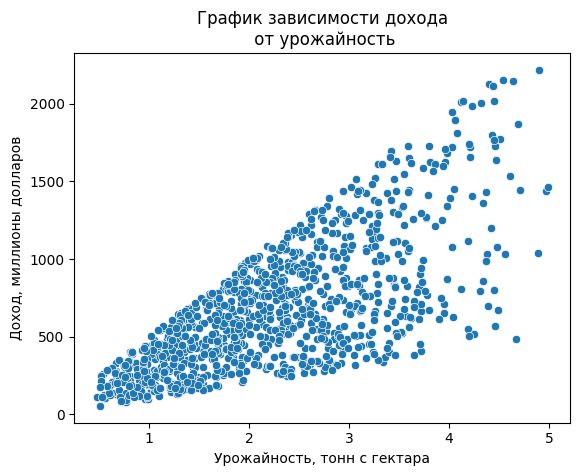

In [ ]:
sns.scatterplot(data=df1, x="Crop_Yield_MT_per_HA", y="Economic_Impact_Million_USD")
plt.xlabel('Урожайность, тонн с гектара')
plt.ylabel('Доход, миллионы долларов')
plt.title('График зависимости дохода\n от урожайность')

По графику видно,что урожайность является одним из ключевых факторов увеличения доходов. Поэтому для заполнения пропусков в колонке Economic_Impact_Million_USD (доход) можем пользоваться данными об урожайности.

In [ ]:
#отсортируем датафрейм по возрастанию урожайности
df1 = df1.sort_values(['Crop_Yield_MT_per_HA']).reset_index()

In [ ]:
df1_new = df1.copy()
df1_new2 = df1.copy()

In [ ]:
#удалим 6 значений дохода в df1_new и df1_new2
df1_new.Economic_Impact_Million_USD[8], df1_new2.Economic_Impact_Million_USD[8] = np.nan,np.nan
df1_new.Economic_Impact_Million_USD[39], df1_new2.Economic_Impact_Million_USD[39]  = np.nan, np.nan
df1_new.Economic_Impact_Million_USD[124],df1_new2.Economic_Impact_Million_USD[124]  = np.nan, np.nan
df1_new.Economic_Impact_Million_USD[91],df1_new2.Economic_Impact_Million_USD[91]  = np.nan, np.nan
df1_new.Economic_Impact_Million_USD[695],df1_new2.Economic_Impact_Million_USD[695]  = np.nan, np.nan
df1_new.Economic_Impact_Million_USD[925], df1_new2.Economic_Impact_Million_USD[925] = np.nan, np.nan
print("Количество пропусков: ", df1_new.Economic_Impact_Million_USD.isna().sum())
print("Количество пропусков: ", df1_new2.Economic_Impact_Million_USD.isna().sum())

Количество пропусков:  6
Количество пропусков:  6


Заполним пропуски в df1_new средним по соседним двум значениям.

In [ ]:
df1_new.Economic_Impact_Million_USD[8] = (df1_new.Economic_Impact_Million_USD[7] + df1_new.Economic_Impact_Million_USD[9])/2
df1_new.Economic_Impact_Million_USD[39] = (df1_new.Economic_Impact_Million_USD[38] + df1_new.Economic_Impact_Million_USD[40])/2
df1_new.Economic_Impact_Million_USD[124] = (df1_new.Economic_Impact_Million_USD[123] + df1_new.Economic_Impact_Million_USD[125])/2
df1_new.Economic_Impact_Million_USD[91] = (df1_new.Economic_Impact_Million_USD[90] + df1_new.Economic_Impact_Million_USD[92])/2
df1_new.Economic_Impact_Million_USD[625] = (df1_new.Economic_Impact_Million_USD[624] + df1_new.Economic_Impact_Million_USD[626])/2
df1_new.Economic_Impact_Million_USD[925] = (df1_new.Economic_Impact_Million_USD[924] + df1_new.Economic_Impact_Million_USD[926])/2

df1_new.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD

,Economic_Impact_Million_USD
8,110.780
39,273.835
124,303.165
91,245.035
625,1001.815
925,1550.035


Заполним пропуски в df1_new2 по всем значениям.

In [ ]:
m = df1_new2['Economic_Impact_Million_USD'].mean()
df1_new2.Economic_Impact_Million_USD[8] = m
df1_new2.Economic_Impact_Million_USD[39] = m
df1_new2.Economic_Impact_Million_USD[124] = m
df1_new2.Economic_Impact_Million_USD[91] = m
df1_new2.Economic_Impact_Million_USD[625] = m
df1_new2.Economic_Impact_Million_USD[925] = m
df1_new2.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD

,Economic_Impact_Million_USD
8,666.718258
39,666.718258
124,666.718258
91,666.718258
625,666.718258
925,666.718258


In [ ]:
df1.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD

,Economic_Impact_Million_USD
8,122.66
39,216.60
124,243.60
91,121.94
625,1187.89
925,561.86


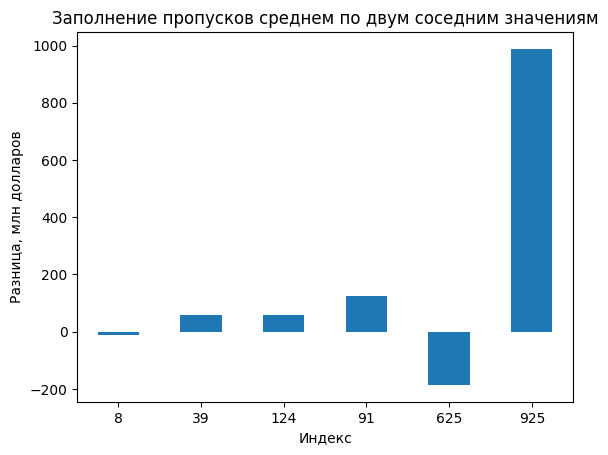

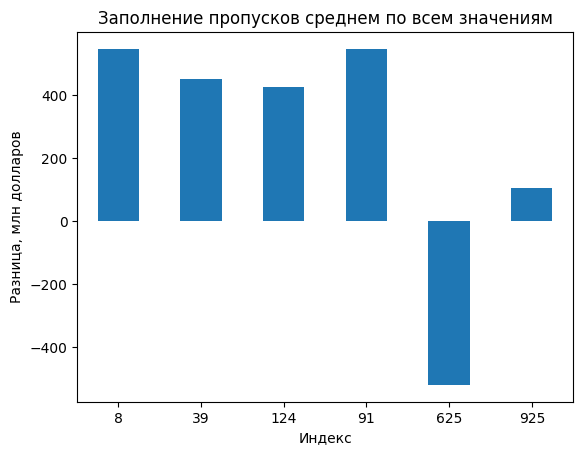

In [ ]:
data_1 = pd.Series(df1_new.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD, index=[8, 39, 124, 91, 625, 925], name="df1_new")
data0= pd.Series(df1.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD,  index=[8, 39, 124, 91, 625, 925],  name="df1")
data_2 =  pd.Series(df1_new2.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD,  index=[8, 39, 124, 91, 625, 925],  name="df1")
# Вычисляем разницу между двумя рядами
dif1 = data_1 - data0
dif2 = data_2 - data0
# Построение бар-графика разницы
dif1.plot(kind='bar')
plt.title("Заполнение пропусков среднем по двум соседним значениям")
plt.xticks(rotation =0 )
plt.xlabel("Индекс")
plt.ylabel("Разница, млн долларов")
plt.show()
dif2.plot(kind='bar')
plt.title("Заполнение пропусков среднем по всем значениям")
plt.xticks(rotation =0 )
plt.xlabel("Индекс")
plt.ylabel("Разница, млн долларов")
plt.show()

По графикам видно, что в большинстве случаях погрешности при заполнении пропусков среднем по двум соседним значениям значительно меньше, чем при заполнении пропусков среднем по всем значениям. Однако заполонённые значения первым методом все равно достаточно сильно отличаются от истинных значений и имеют огромный выброс.

Можно усложнить метод и сортировать датафрейм не только по урожайности, но и по году.

In [ ]:
df1= pd.read_csv("impact_on_agriculture_2024.csv")
df1 = df1.sort_values(['Crop_Yield_MT_per_HA', 'Year']).reset_index()
df1_new3 = df1.copy()
df1_new3.Economic_Impact_Million_USD[8]= np.nan
df1_new3.Economic_Impact_Million_USD[39]= np.nan
df1_new3.Economic_Impact_Million_USD[124]= np.nan
df1_new3.Economic_Impact_Million_USD[91]= np.nan
df1_new3.Economic_Impact_Million_USD[695]= np.nan
df1_new3.Economic_Impact_Million_USD[925]= np.nan
print("Количество пропусков: ", df1_new3.Economic_Impact_Million_USD.isna().sum())

Количество пропусков:  6


In [ ]:
df1_new3.Economic_Impact_Million_USD[8] = (df1_new3.Economic_Impact_Million_USD[7] + df1_new3.Economic_Impact_Million_USD[9])/2
df1_new3.Economic_Impact_Million_USD[39] = (df1_new3.Economic_Impact_Million_USD[38] + df1_new3.Economic_Impact_Million_USD[40])/2
df1_new3.Economic_Impact_Million_USD[124] = (df1_new3.Economic_Impact_Million_USD[123] + df1_new3.Economic_Impact_Million_USD[125])/2
df1_new3.Economic_Impact_Million_USD[91] = (df1_new3.Economic_Impact_Million_USD[90] + df1_new3.Economic_Impact_Million_USD[92])/2
df1_new3.Economic_Impact_Million_USD[625] = (df1_new3.Economic_Impact_Million_USD[624] + df1_new3.Economic_Impact_Million_USD[626])/2
df1_new3.Economic_Impact_Million_USD[925] = (df1_new3.Economic_Impact_Million_USD[924] + df1_new3.Economic_Impact_Million_USD[926])/2
df1_new3.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD

,Economic_Impact_Million_USD
8,144.165
39,213.820
124,145.875
91,174.530
625,355.535
925,157.560


In [ ]:
df1.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD

,Economic_Impact_Million_USD
8,127.69
39,69.96
124,86.43
91,232.33
625,324.82
925,400.86


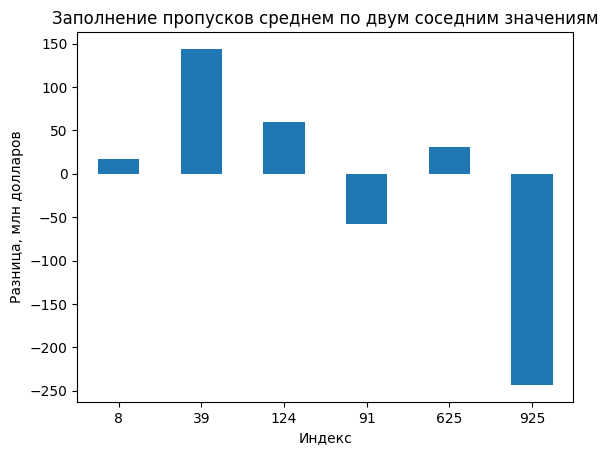

In [ ]:
data_3 = pd.Series(df1_new3.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD, index=[8, 39, 124, 91, 625, 925], name="df1_new3")
data0= pd.Series(df1.iloc[[8,39,124,91,625,925]].Economic_Impact_Million_USD,  index=[8, 39, 124, 91, 625, 925],  name="df0")
# Вычисляем разницу между двумя рядами
dif3 = data_3 - data0
# Построение бар-графика разницы
dif3.plot(kind='bar')
plt.title("Заполнение пропусков среднем по двум соседним значениям")
plt.xticks(rotation =0 )
plt.xlabel("Индекс")
plt.ylabel("Разница, млн долларов")
plt.show()

Этот метод работает лучше, чем предыдущие, так как большинство погрешностей не превышают 50 млн. Здесь также  присутствует выброс, однако он значительно меньше, чем в предыдущих случаях.

Теперь повторим то же самое на языке R, но для других срочек

In [ ]:
%%R
# Сортировка данных по возрастанию урожайности и Сброс индексов
df1r <- df1r[order(c(df1r$Crop_Yield_MT_per_HA)), ]
df1r_new1 <- df1r
df1r_new2 <- df1r
df1r_new3 <- df1r

# Заменяем 6 значений на NA
indices_na <- c(5, 10 , 134, 456, 670, 1001)
df1r_new1$Economic_Impact_Million_USD[indices_na] <- NA
df1r_new2$Economic_Impact_Million_USD[indices_na] <- NA
df1r_new3$Economic_Impact_Million_USD[indices_na] <- NA

#Проверяем количество пропусков
na_count_new1 <- sum(is.na(df1r_new1$Economic_Impact_Million_USD))
na_count_new2 <- sum(is.na(df1r_new2$Economic_Impact_Million_USD))
na_count_new3 <- sum(is.na(df1r_new3$Economic_Impact_Million_USD))

cat("Количество пропусков в df1r_new1:", na_count_new1, "\n")
cat("Количество пропусков в df1r_new2:", na_count_new2, "\n")
cat("Количество пропусков в df1r_new3:", na_count_new3, "\n")

Количество пропусков в df1r_new1: 6 
Количество пропусков в df1r_new2: 6 
Количество пропусков в df1r_new3: 6 


In [ ]:
%%R
#Замена пропусков средними соседних значений
for (i in indices_na) {
  df1r_new1$Economic_Impact_Million_USD[i] <-
    (df1r_new1$Economic_Impact_Million_USD[i - 1] + df1r_new1$Economic_Impact_Million_USD[i + 1]) / 2
}

# Замена пропусков на среднее значение
m <- mean(df1r_new2$Economic_Impact_Million_USD, na.rm = TRUE)
df1r_new2$Economic_Impact_Million_USD[indices_na] <- m


# Проверяем обновленные строки
print(df1r_new1[indices_na, "Economic_Impact_Million_USD"])
print(df1r_new2[indices_na, "Economic_Impact_Million_USD"])
print(df1r[indices_na, "Economic_Impact_Million_USD"])


[1]  161.240  204.850  495.360  567.660  528.415 1656.975
[1] 667.5516 667.5516 667.5516 667.5516 667.5516 667.5516
[1]  285.96  661.98  134.41  128.16  699.05 1297.27


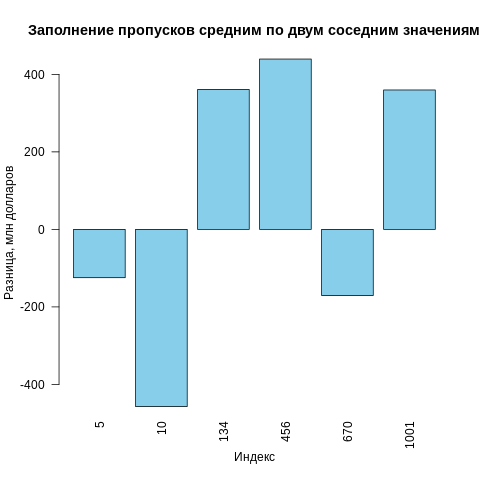

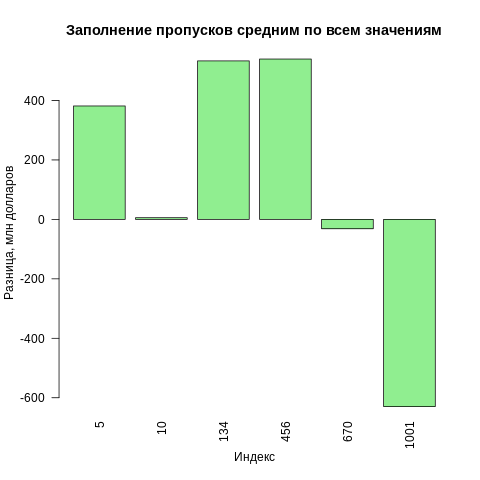

In [ ]:
%%R
data_0 <- df1r$Economic_Impact_Million_USD[indices_na]
data_1 <- df1r_new1$Economic_Impact_Million_USD[indices_na]
data_2 <- df1r_new2$Economic_Impact_Million_USD[indices_na]
dif1 <- data_1 - data_0
dif2 <- data_2 - data_0

# Построение графиков
barplot(dif1, names.arg = indices_na, main = "Заполнение пропусков средним по двум соседним значениям",
        xlab = "Индекс", ylab = "Разница, млн долларов",
        col = "skyblue", las = 2)

barplot(dif2,
        names.arg = indices_na, main = "Заполнение пропусков средним по всем значениям",
        xlab = "Индекс", ylab = "Разница, млн долларов",
        col = "lightgreen", las = 2)


In [ ]:
%%R
df1r <- df1r[order(df1r$Crop_Yield_MT_per_HA, df1r$Year), ]
rownames(df1r) <- NULL
df1r_new3 <- df1r
indices_na <- c(5, 10 , 134, 456, 670, 1001)
df1r_new3$Economic_Impact_Million_USD[indices_na] <- NA
# Заполняем пропуски средним значением двух соседних строк
for (i in indices_na) {
  df1r_new3$Economic_Impact_Million_USD[i] <-
    (df1r_new3$Economic_Impact_Million_USD[i - 1] +
     df1r_new3$Economic_Impact_Million_USD[i + 1]) / 2
}

# Проверяем обновленные значения строк с пропусками
print(df1r[indices_na, "Economic_Impact_Million_USD"])
print(df1r_new3[indices_na, "Economic_Impact_Million_USD"])

[1]  248.20  106.64  120.29  565.12  313.22 1801.86
[1]  161.240  204.850  495.360  567.660  527.575 1656.975


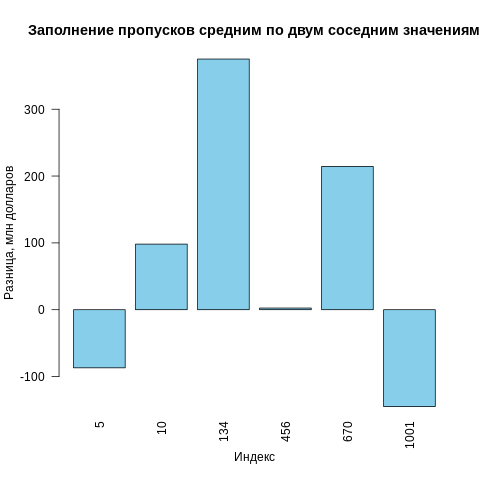

In [ ]:
%%R
# Построение графика
data_0 <- df1r$Economic_Impact_Million_USD[indices_na]
data_3 <- df1r_new3$Economic_Impact_Million_USD[indices_na]
dif3 <- data_3 - data_0
barplot(dif3, names.arg = indices_na, main = "Заполнение пропусков средним по двум соседним значениям",
        xlab = "Индекс", ylab = "Разница, млн долларов",
        col = "skyblue", las = 2)

# **Задание 6**

*Сгенерировать данные из нормального распределения с различными
параметрами и провести анализ с помощью графиков эмпирических функций
распределений, квантилей, метода огибающих, а также стандартных процедур
проверки гипотез о нормальности (критерии Колмогорова-Смирнова, ШапироУилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в
модификации Лиллиефорса и Шапиро-Франсия). Рассмотреть выборки малого
(не более 50-100 элементов) и умеренного (1000-5000 наблюдений) объемо*


In [ ]:
d1 = np.random.normal(0, 2, size = 75)
d2 = np.random.normal(10, 3, size = 75)
d3 = np.random.normal(0, 1, size = 2500)
d4 = np.random.normal(2, 5, size = 2500)

In [ ]:
%%R

d1 <- rnorm(75, mean = 0, sd = 2)
d2 <- rnorm(75, mean = 10, sd = 3)
d3 <- rnorm(2500, mean = 0, sd = 1)
d4 <- rnorm(2500, mean = 2, sd = 5)

**Эмпирические функции распределений**

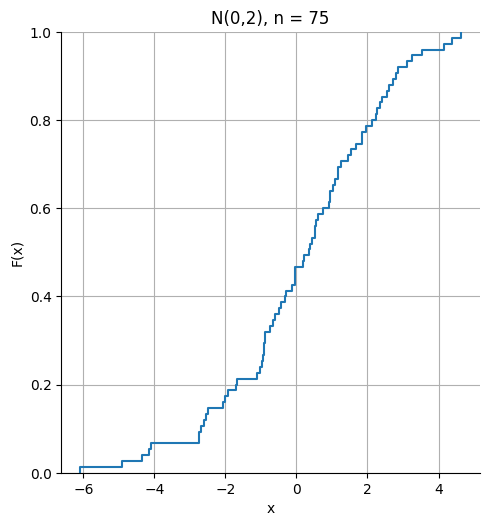

In [ ]:
sns.displot(data = d1, kind = "ecdf").set(title='N(0,2), n = 75',xlabel ='x', ylabel = 'F(x)')
plt.grid(True)

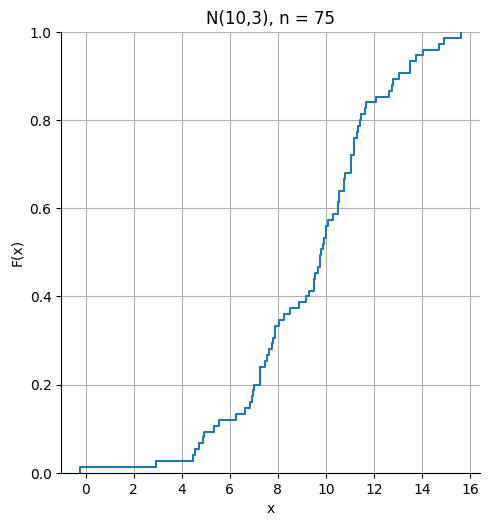

In [ ]:
sns.displot(data = d2, kind = "ecdf").set(title='N(10,3), n = 75', xlabel ='x', ylabel = 'F(x)')
plt.grid(True)

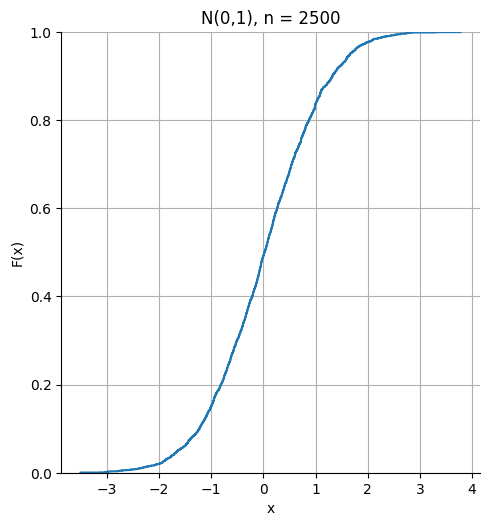

In [ ]:
sns.displot(data = d3, kind = "ecdf").set(title='N(0,1), n = 2500', xlabel ='x', ylabel = 'F(x)')
plt.grid(True)

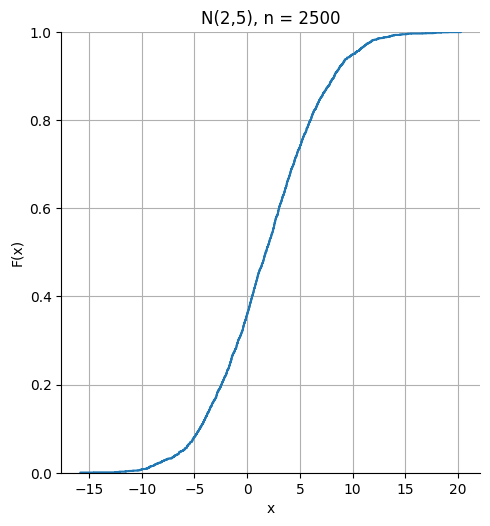

In [ ]:
sns.displot(data = d4, kind = "ecdf").set(title='N(2,5), n = 2500', xlabel ='x', ylabel = 'F(x)')
plt.grid(True)

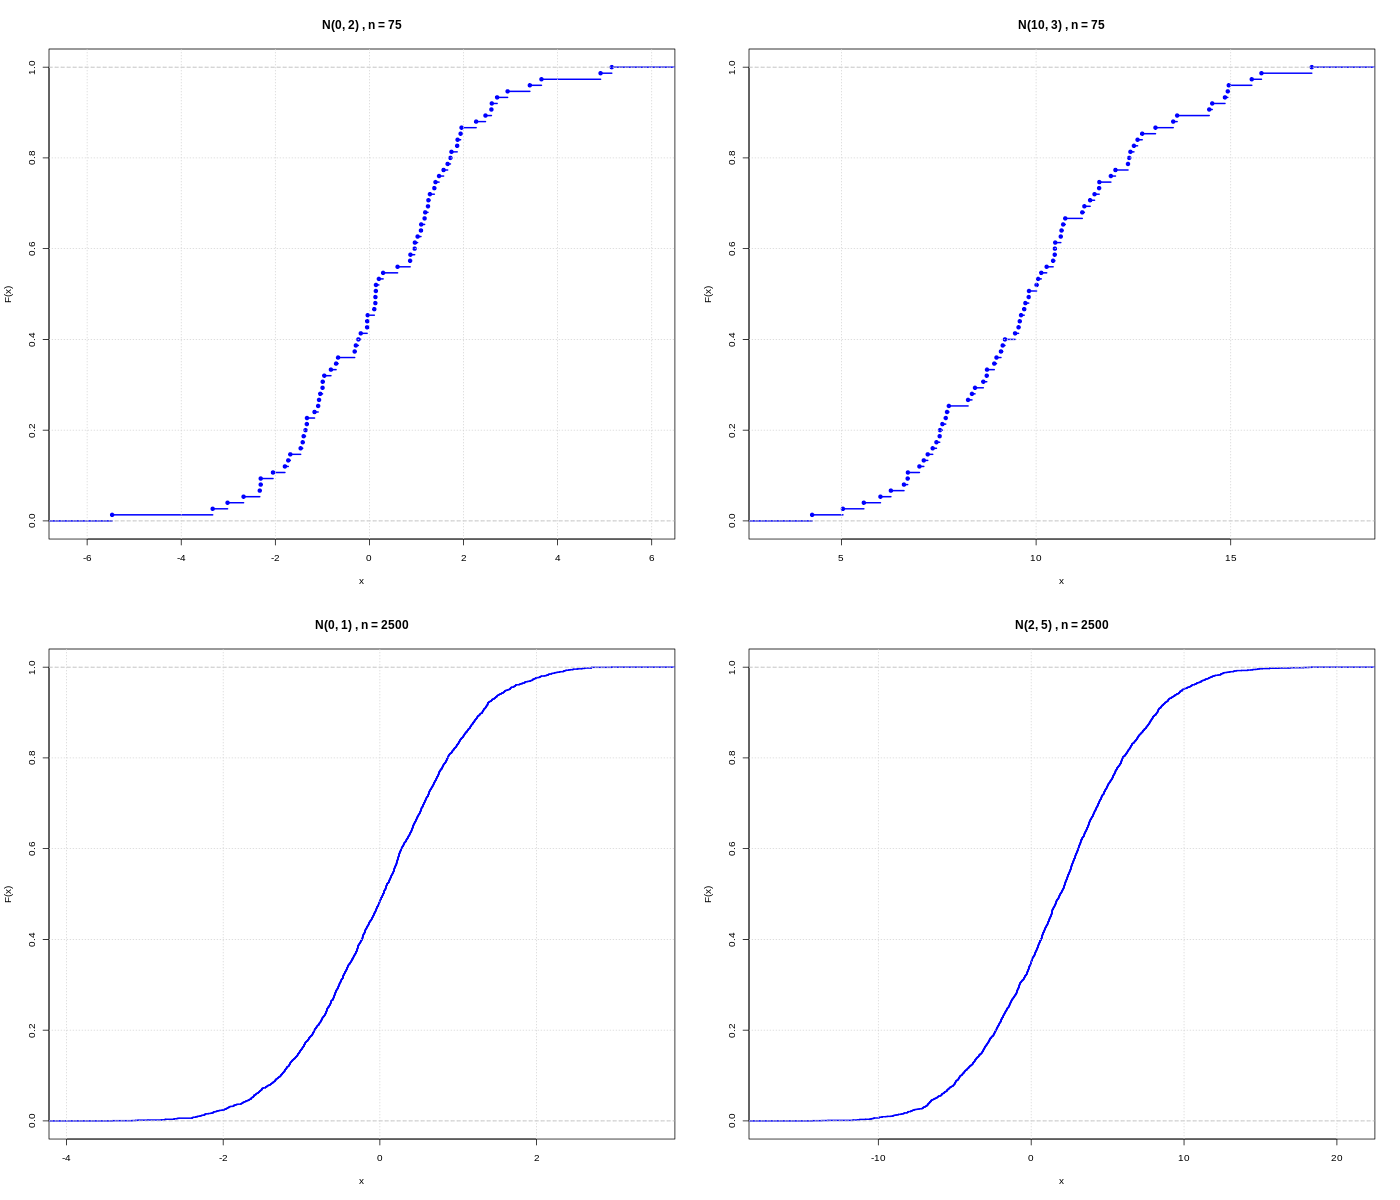

In [ ]:
%%R -w 1400 -h 1200
plot_ecdf <- function(data, main_title, n_label) {
  plot(ecdf(data),
       main = paste(main_title, ", n =", n_label),
       xlab = "x",
       ylab = "F(x)",
       col = "blue",
       lwd = 2)
  grid()
}

# Построение графиков
par(mfrow = c(2, 2)) # Разделение области графиков на 4
plot_ecdf(d1, "N(0, 2)", 75)
plot_ecdf(d2, "N(10, 3)", 75)
plot_ecdf(d3, "N(0, 1)", 2500)
plot_ecdf(d4, "N(2, 5)", 2500)

**Квантили**

Text(0.5, 1.0, 'Q-Q Plot    N(0,2), n = 75')

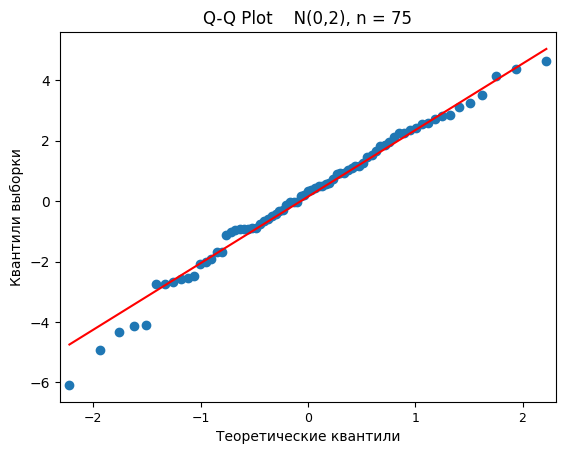

In [ ]:
sm.qqplot(d1, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Q-Q Plot    N(0,2), n = 75')

Text(0.5, 1.0, 'Q-Q Plot    N(10,3), n = 75')

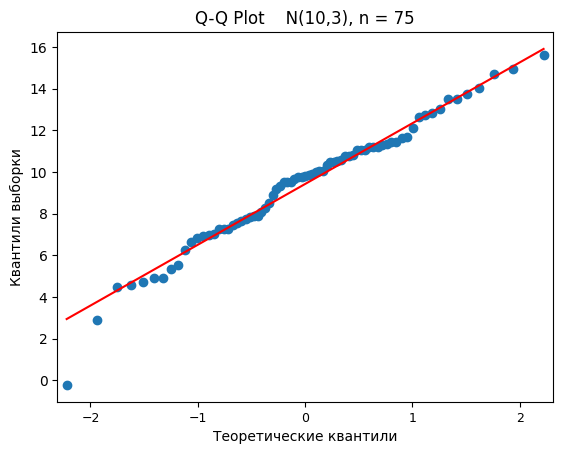

In [ ]:
sm.qqplot(d2, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Q-Q Plot    N(10,3), n = 75')

Text(0.5, 1.0, 'Q-Q Plot    N(0,1), n = 2500')

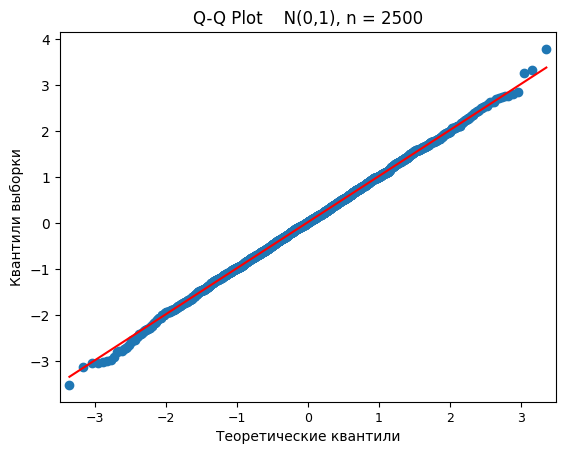

In [ ]:
sm.qqplot(d3, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Q-Q Plot    N(0,1), n = 2500')

Text(0.5, 1.0, 'Q-Q Plot    N(2,5), n = 2500')

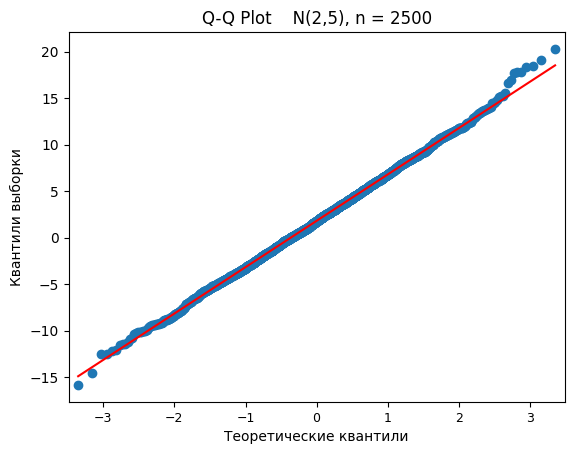

In [ ]:
sm.qqplot(d4, line='s')
plt.xticks(fontsize=9)
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Q-Q Plot    N(2,5), n = 2500')

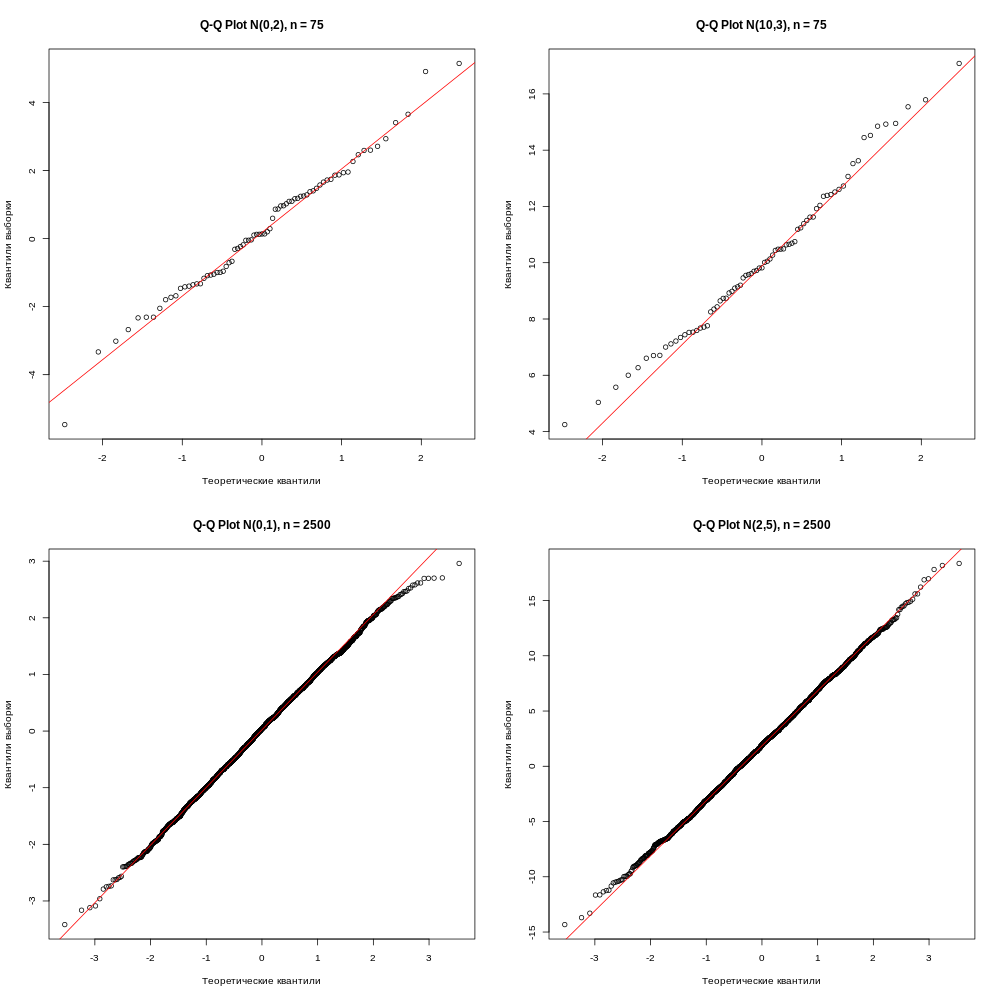

In [ ]:
%%R -w 1000 -h 1000

par(mfrow = c(2, 2))
qqnorm(d1, main = "Q-Q Plot N(0,2), n = 75", xlab = "Теоретические квантили", ylab = "Квантили выборки")
qqline(d1, col = "red")

qqnorm(d2, main = "Q-Q Plot N(10,3), n = 75", xlab = "Теоретические квантили", ylab = "Квантили выборки")
qqline(d2, col = "red")

qqnorm(d3, main = "Q-Q Plot N(0,1), n = 2500", xlab = "Теоретические квантили", ylab = "Квантили выборки")
qqline(d3, col = "red")

qqnorm(d4, main = "Q-Q Plot N(2,5), n = 2500", xlab = "Теоретические квантили", ylab = "Квантили выборки")
qqline(d4, col = "red")


**Метод огибающих**

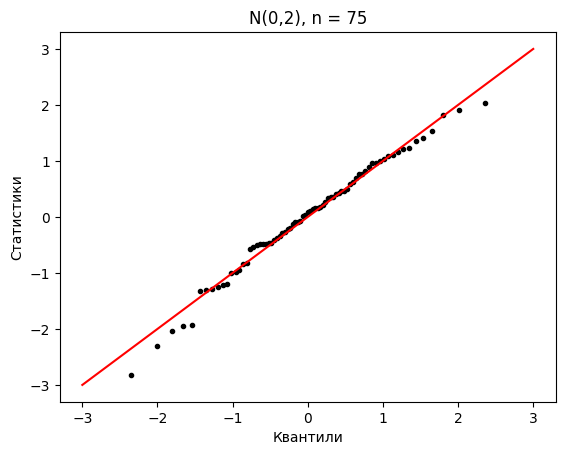

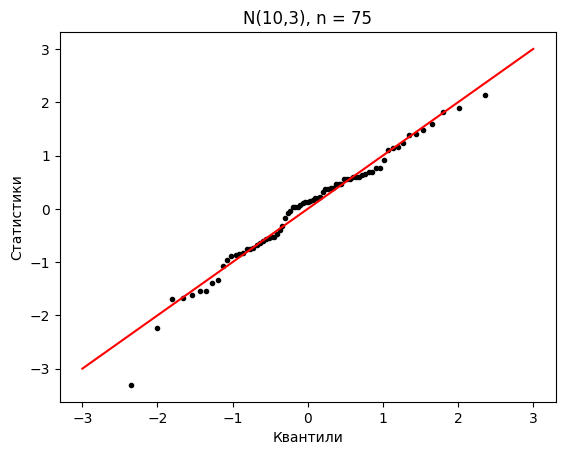

In [ ]:
def envelmet(x, text):
    z = (x - x.mean()) / x.std()
    x_qq, _ = stats.probplot(z)
    plt.plot(x_qq[0], x_qq[1], '.k')
    plt.plot((-3, 3), (-3, 3), c='red')
    plt.tick_params(axis='both')
    plt.xlabel('Квантили')
    plt.ylabel('Статистики')
    plt.title(text)


envelmet(d1, 'N(0,2), n = 75')
plt.show()
envelmet(d2, 'N(10,3), n = 75')
plt.show()

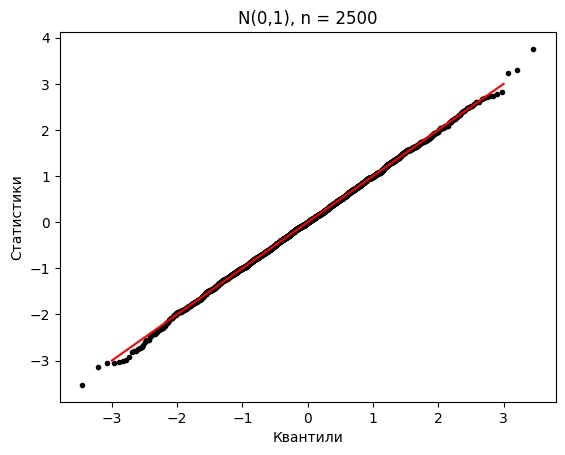

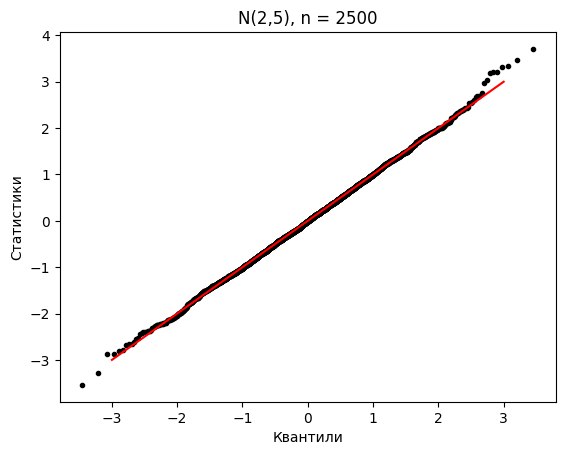

In [ ]:
envelmet(d3, 'N(0,1), n = 2500')
plt.show()
envelmet(d4, 'N(2,5), n = 2500')
plt.show()

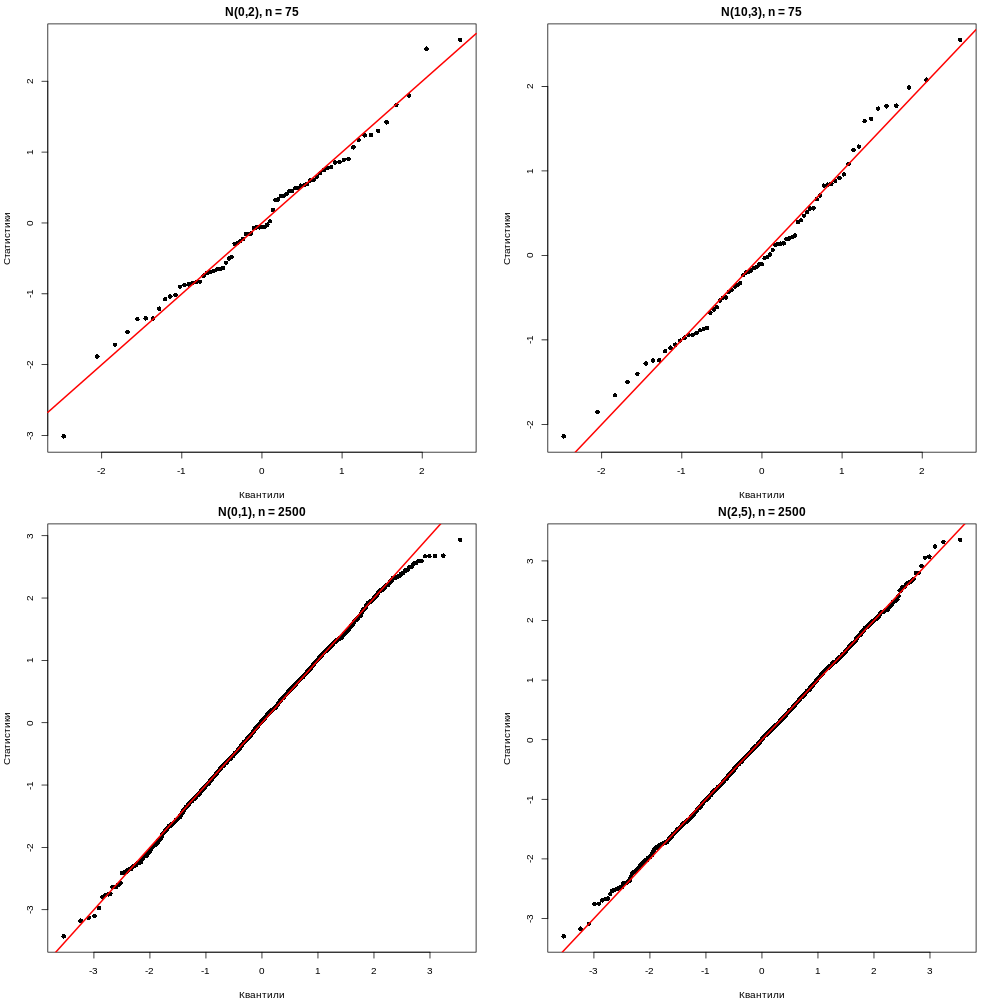

In [ ]:
%%R  -w 1000 -h 1000
envelope_plot <- function(data, text) {
  z <- (data - mean(data)) / sd(data)
  qq <- qqnorm(z, plot.it = FALSE)
  plot(qq$x, qq$y, main = text,
       xlab = "Квантили", ylab = "Статистики",
       col = "black", pch = 16)
  abline(a = 0, b = 1, col = "red", lwd = 2)
}
par(mfrow = c(2, 2), mar = c(4, 4, 2, 2))

envelope_plot(d1, "N(0,2), n = 75")

envelope_plot(d2, "N(10,3), n = 75")

envelope_plot(d3, "N(0,1), n = 2500")

envelope_plot(d4, "N(2,5), n = 2500")

**Проверка гипотез о нормальности**

Формулируется нулевая гипотеза

\$$H_0 : F_n(x) = F(x, \theta_0), \quad x \in \mathbb{R},$

 где $ (F_n(x)) $ — эмпирическая функция распределения, а $(F(x, \theta_0))$ — функция распределения с заданными параметрами.

Проверим гипотезу о том, что выборка была получена из стандартного нормального распределения, положив

$
F(x, \theta_0) \equiv \Phi(x),
$

где $(\Phi(x))$ — функция распределения стандартного нормального закона.

In [ ]:
def check_pval(pval):
  if pval < 0.05:
    return 'Есть основания отклонить гипотезу'
  return 'Нет оснований отклонять гипотезу'
 # Тест Колмогорова-Смирнова
def k_s_test(d, text):
    k_s_test = stats.kstest(d, 'norm', args=(np.mean(d), np.std(d)))
    print(f"Тест Колмогорова-Смирнова для {text}: p-value = {k_s_test.pvalue:.4f} =>",check_pval(k_s_test.pvalue))
# Тест Шапиро-Уилка
def sh_w_test(d, text):
    sh_w_test = stats.shapiro(d)
    print(f"Тест Шапиро-Уилка для {text}: p-value = {sh_w_test.pvalue:.4f} =>",check_pval(sh_w_test.pvalue) )
# Тест Андерсона-Дарлинга
def a_d_test(d, text):
    ad_test = stats.anderson(d, dist='norm')
    print(f"Тест Андерсона-Дарлинга для {text}: statistic = {ad_test.statistic:.4f}")
# Тест Крамера фон Мизеса
def cvm_test(d, text):
    cvm_test = stats.cramervonmises(d, 'norm')
    print(f"Тест Крамера фон Мизеса для {text}: p-value = {cvm_test.pvalue:.10f} =>",check_pval(cvm_test.pvalue))
# Тест Лиллиефорса (модификация Колмогорова-Смирнова)
def l_test(d, text):
    l_test_stat, l_p_value = lilliefors(d)
    print(f"Тест Лиллиефорса для {text}: p-value = {l_p_value:.4f} =>",check_pval(l_p_value) )
text1 = 'N(0,2), n = 75'
text2 = 'N(10,3), n = 75'
text3 = 'N(0,1), n = 2500'
text4 = 'N(2,5), n = 2500'

In [ ]:
%%R
check_pval <- function(pval) {
  if (pval < 0.05) {
    return("Есть основания отклонить гипотезу")
  } else {
    return("Нет оснований отклонять гипотезу")
  }
}
# Тест Колмогорова-Смирнова
ks_test <- function(d, text) {
  ks_result <- ks.test(d, "pnorm", mean(d), sd(d))
  cat(sprintf("Тест Колмогорова-Смирнова для %s: p-value = %.4f => %s\n",
              text, ks_result$p.value, check_pval(ks_result$p.value)))
}
# Тест Шапиро-Уилка
sh_w_test <- function(d, text) {
  sh_result <- shapiro.test(d)
  cat(sprintf("Тест Шапиро-Уилка для %s: p-value = %.4f => %s\n",
              text, sh_result$p.value, check_pval(sh_result$p.value)))
}
# Тест Андерсона-Дарлинга
a_d_test <- function(d, text) {
  library(nortest)
  ad_result <- ad.test(d)
  cat(sprintf("Тест Андерсона-Дарлинга для %s: p-value = %.4f\n",
              text, ad_result$p.value))
}

# Тест Крамера фон Мизеса
cvm_test <- function(d, text) {
  library(nortest)
  cvm_result <- cvm.test(d)
  cat(sprintf("Тест Крамера фон Мизеса для %s: p-value = %.4f => %s\n",
              text, cvm_result$p.value, check_pval(cvm_result$p.value)))
}

# Тест Лиллиефорса
l_test <- function(d, text) {
  library(nortest)
  lillie_result <- lillie.test(d)
  cat(sprintf("Тест Лиллиефорса для %s: p-value = %.4f => %s\n",
              text, lillie_result$p.value, check_pval(lillie_result$p.value)))
}
text1 <- "N(0,2), n = 75"
text2 <- "N(10,3), n = 75"
text3 <- "N(0,1), n = 2500"
text4 <- "N(2,5), n = 2500"

In [ ]:
%%R
install.packages("nortest")
library(nortest)

In [ ]:
print('Тест Колмогорова-Смирнова')
k_s_test(d1, text1)
k_s_test(d2, text2)
k_s_test(d3, text3)
k_s_test(d4, text4)

Тест Колмогорова-Смирнова
Тест Колмогорова-Смирнова для N(0,2), n = 75: p-value = 0.8231 => Нет оснований отклонять гипотезу
Тест Колмогорова-Смирнова для N(10,3), n = 75: p-value = 0.4530 => Нет оснований отклонять гипотезу
Тест Колмогорова-Смирнова для N(0,1), n = 2500: p-value = 0.9879 => Нет оснований отклонять гипотезу
Тест Колмогорова-Смирнова для N(2,5), n = 2500: p-value = 0.8823 => Нет оснований отклонять гипотезу


In [ ]:
%%R
ks_test(d1, text1)
ks_test(d2, text2)
ks_test(d3, text3)
ks_test(d4, text4)

Тест Колмогорова-Смирнова для N(0,2), n = 75: p-value = 0.8549 => Нет оснований отклонить гипотезу
Тест Колмогорова-Смирнова для N(10,3), n = 75: p-value = 0.7865 => Нет оснований отклонить гипотезу
Тест Колмогорова-Смирнова для N(0,1), n = 2500: p-value = 0.7754 => Нет оснований отклонить гипотезу
Тест Колмогорова-Смирнова для N(2,5), n = 2500: p-value = 0.9918 => Нет оснований отклонить гипотезу


In [ ]:
print('Тест Шапиро-Уилка')
sh_w_test(d1, text1)
sh_w_test(d2, text2)
sh_w_test(d3, text3)
sh_w_test(d4, text4)

Тест Шапиро-Уилка
Тест Шапиро-Уилка для N(0,2), n = 75: p-value = 0.5311 => Нет оснований отклонять гипотезу
Тест Шапиро-Уилка для N(10,3), n = 75: p-value = 0.2747 => Нет оснований отклонять гипотезу
Тест Шапиро-Уилка для N(0,1), n = 2500: p-value = 0.9476 => Нет оснований отклонять гипотезу
Тест Шапиро-Уилка для N(2,5), n = 2500: p-value = 0.5329 => Нет оснований отклонять гипотезу


In [ ]:
%%R
sh_w_test(d1, text1)
sh_w_test(d2, text2)
sh_w_test(d3, text3)
sh_w_test(d4, text4)

Тест Шапиро-Уилка для N(0,2), n = 75: p-value = 0.7485 => Нет оснований отклонять гипотезу
Тест Шапиро-Уилка для N(10,3), n = 75: p-value = 0.5664 => Нет оснований отклонять гипотезу
Тест Шапиро-Уилка для N(0,1), n = 2500: p-value = 0.1360 => Нет оснований отклонять гипотезу
Тест Шапиро-Уилка для N(2,5), n = 2500: p-value = 0.8106 => Нет оснований отклонять гипотезу


In [ ]:
print('Тест Андерсона-Дарлинга')
a_d_test(d1, text1)
a_d_test(d2, text2)
a_d_test(d3, text3)
a_d_test(d4, text4)

Тест Андерсона-Дарлинга
Тест Андерсона-Дарлинга для N(0,2), n = 75: statistic = 0.2809
Тест Андерсона-Дарлинга для N(10,3), n = 75: statistic = 0.4601
Тест Андерсона-Дарлинга для N(0,1), n = 2500: statistic = 0.1709
Тест Андерсона-Дарлинга для N(2,5), n = 2500: statistic = 0.2325


In [ ]:
%%R
a_d_test(d1, text1)
a_d_test(d2, text2)
a_d_test(d3, text3)
a_d_test(d4, text4)

Тест Андерсона-Дарлинга для N(0,2), n = 75: p-value = 0.6038
Тест Андерсона-Дарлинга для N(10,3), n = 75: p-value = 0.5046
Тест Андерсона-Дарлинга для N(0,1), n = 2500: p-value = 0.3501
Тест Андерсона-Дарлинга для N(2,5), n = 2500: p-value = 0.8443


In [ ]:
print('Тест Крамера фон Мизеса')
cvm_test(d1, text1)
cvm_test(d2, text2)
cvm_test(d3, text3)
cvm_test(d4, text4)

Тест Крамера фон Мизеса
Тест Крамера фон Мизеса для N(0,2), n = 75: p-value = 0.0004925268 => Есть основания отклонить гипотезу
Тест Крамера фон Мизеса для N(10,3), n = 75: p-value = 0.0000000016 => Есть основания отклонить гипотезу
Тест Крамера фон Мизеса для N(0,1), n = 2500: p-value = 0.3138071748 => Нет оснований отклонять гипотезу
Тест Крамера фон Мизеса для N(2,5), n = 2500: p-value = 0.0000000627 => Есть основания отклонить гипотезу


In [ ]:
%%R
cvm_test(d1, text1)
cvm_test(d2, text2)
cvm_test(d3, text3)
cvm_test(d4, text4)

Тест Крамера фон Мизеса для N(0,2), n = 75: p-value = 0.5880 => Нет оснований отклонять гипотезу
Тест Крамера фон Мизеса для N(10,3), n = 75: p-value = 0.5388 => Нет оснований отклонять гипотезу
Тест Крамера фон Мизеса для N(0,1), n = 2500: p-value = 0.3128 => Нет оснований отклонять гипотезу
Тест Крамера фон Мизеса для N(2,5), n = 2500: p-value = 0.8858 => Нет оснований отклонять гипотезу


In [ ]:
print('Тест Лиллиефорса')
l_test(d1, text1)
l_test(d2, text2)
l_test(d3, text3)
l_test(d4, text4)

Тест Лиллиефорса
Тест Лиллиефорса для N(0,2), n = 75: p-value = 0.5047 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для N(10,3), n = 75: p-value = 0.1129 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для N(0,1), n = 2500: p-value = 0.9132 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для N(2,5), n = 2500: p-value = 0.5798 => Нет оснований отклонять гипотезу


In [ ]:
%%R
l_test(d1, text1)
l_test(d2, text2)
l_test(d3, text3)
l_test(d4, text4)

Тест Лиллиефорса для N(0,2), n = 75: p-value = 0.5305 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для N(10,3), n = 75: p-value = 0.4070 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для N(0,1), n = 2500: p-value = 0.3616 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для N(2,5), n = 2500: p-value = 0.9203 => Нет оснований отклонять гипотезу


# **Задание 7**

*Продемонстрировать пример анализа данных с помощью графиков
квантилей, метода огибающих, а также стандартных процедур проверки гипотез
о нормальности. Рассмотреть выборки малого и умеренного объемов.*


In [ ]:
small_df = df1[0:100]

In [ ]:
%%R
small_df1r <- df1r[1:100, ]

Text(5.069444444444445, 0.5, 'Количество')

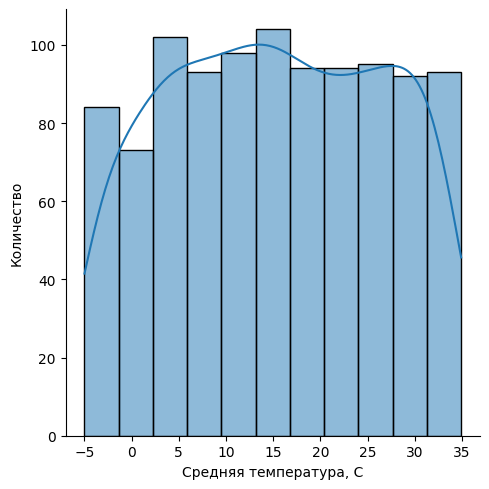

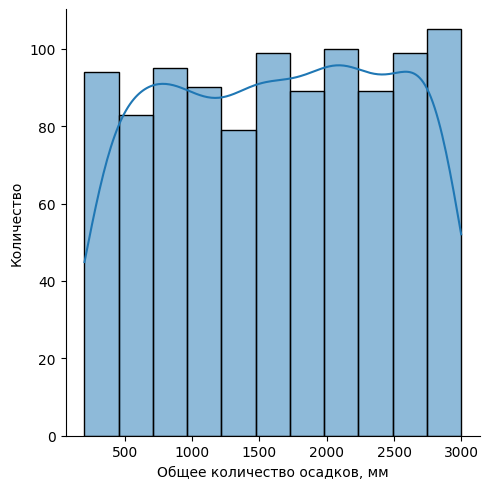

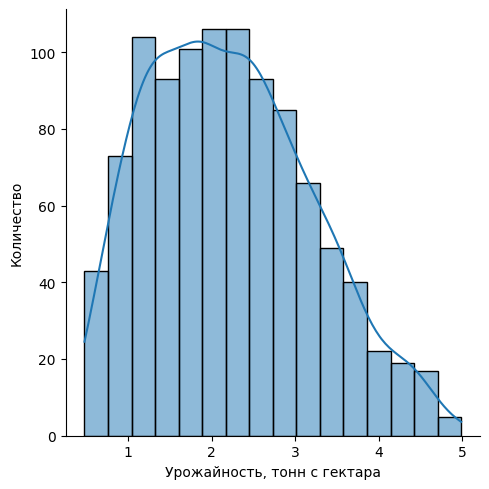

In [ ]:
sns.displot(x = 'Average_Temperature_C', data = df1, kde = True)
plt.xlabel('Средняя температура, С')
plt.ylabel('Количество')
sns.displot(x = 'Total_Precipitation_mm', data = df1, kde = True)
plt.xlabel('Общее количество осадков, мм')
plt.ylabel('Количество')
sns.displot(x= 'Crop_Yield_MT_per_HA',data = df1, kde = True )
plt.xlabel('Урожайность, тонн с гектара')
plt.ylabel('Количество')

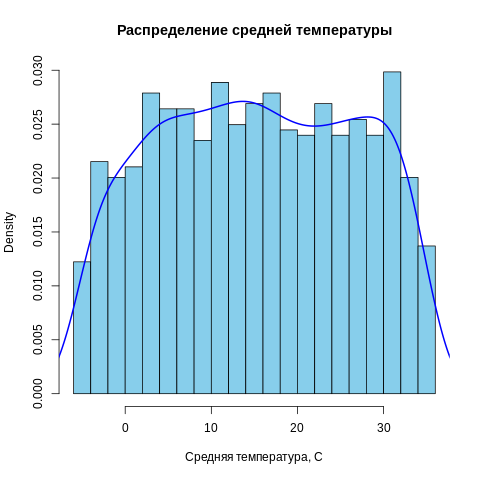

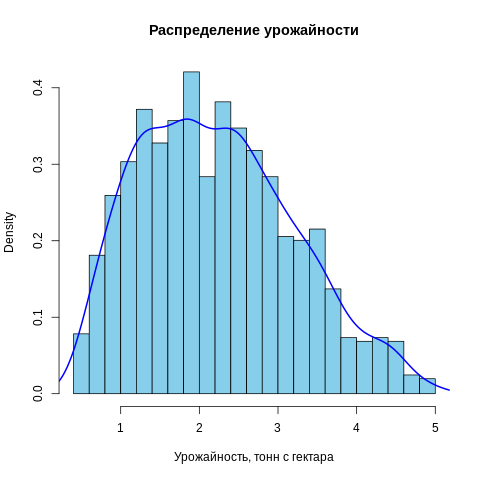

In [ ]:
%%R
hist(df1r$Average_Temperature_C,
     breaks = 20, # Количество интервалов
     col = "skyblue", # Цвет гистограммы
     border = "black", # Цвет границ столбцов
     prob = TRUE, # Нормируем для плотности
     xlab = "Средняя температура, C",
     main = "Распределение средней температуры")
lines(density(df1r$Average_Temperature_C), # Кривая плотности
      col = "blue",
      lwd = 2) # Толщина линии

hist(df1r$Crop_Yield_MT_per_HA,
     breaks = 20,
     col = "skyblue",
     border = "black",
     prob = TRUE,
     xlab = "Урожайность, тонн с гектара",
     main = "Распределение урожайности")
lines(density(df1r$Crop_Yield_MT_per_HA),
      col = "blue",
      lwd = 2)

**Графики квантилей**

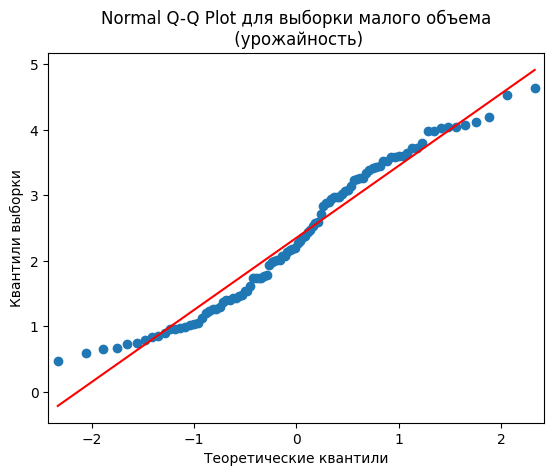

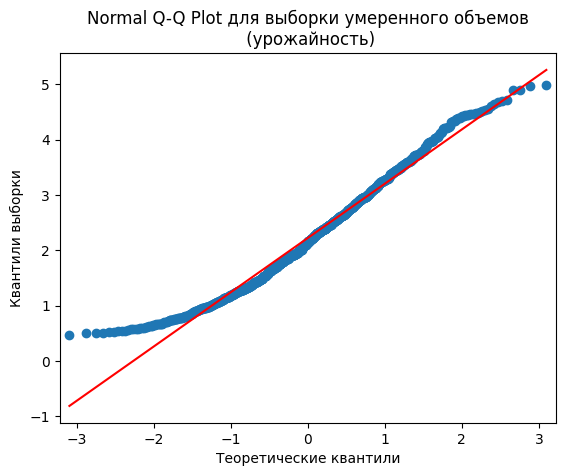

In [ ]:
sm.qqplot(small_df.Crop_Yield_MT_per_HA, line='s')
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Normal Q-Q Plot для выборки малого объема\n (урожайность)')
sm.qqplot(df1.Crop_Yield_MT_per_HA, line = 's')
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Normal Q-Q Plot для выборки умеренного объемов\n (урожайность)')
plt.show()

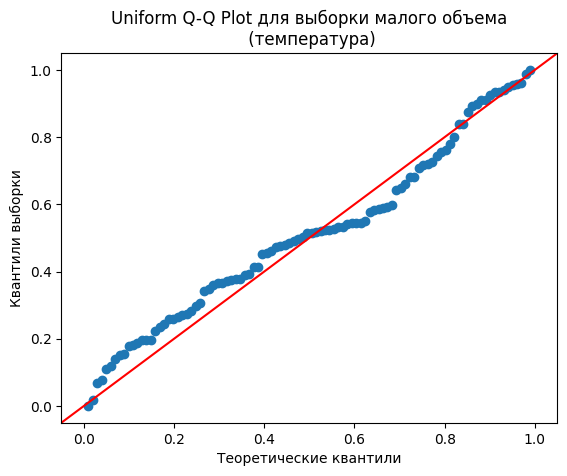

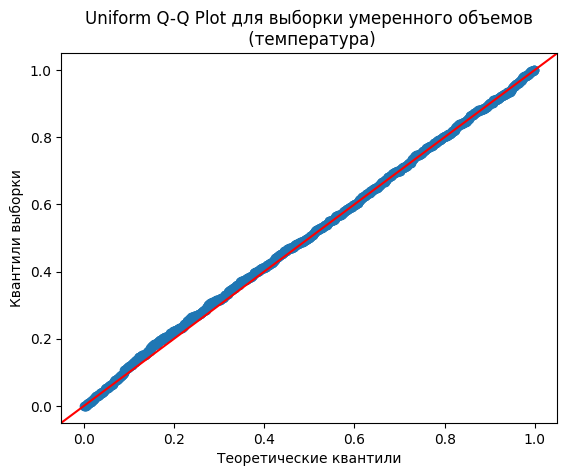

In [ ]:
sm.qqplot(small_df.Average_Temperature_C, stats.uniform, fit=True,line="45")#проверка на равномерное распределение
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Uniform Q-Q Plot для выборки малого объема\n (температура)')
sm.qqplot(df1.Average_Temperature_C, stats.uniform, fit=True,line="45")##проверка на равномерное распределение
plt.xlabel('Теоретические квантили')
plt.ylabel('Квантили выборки')
plt.title('Uniform Q-Q Plot для выборки умеренного объемов\n (температура)')
plt.show()

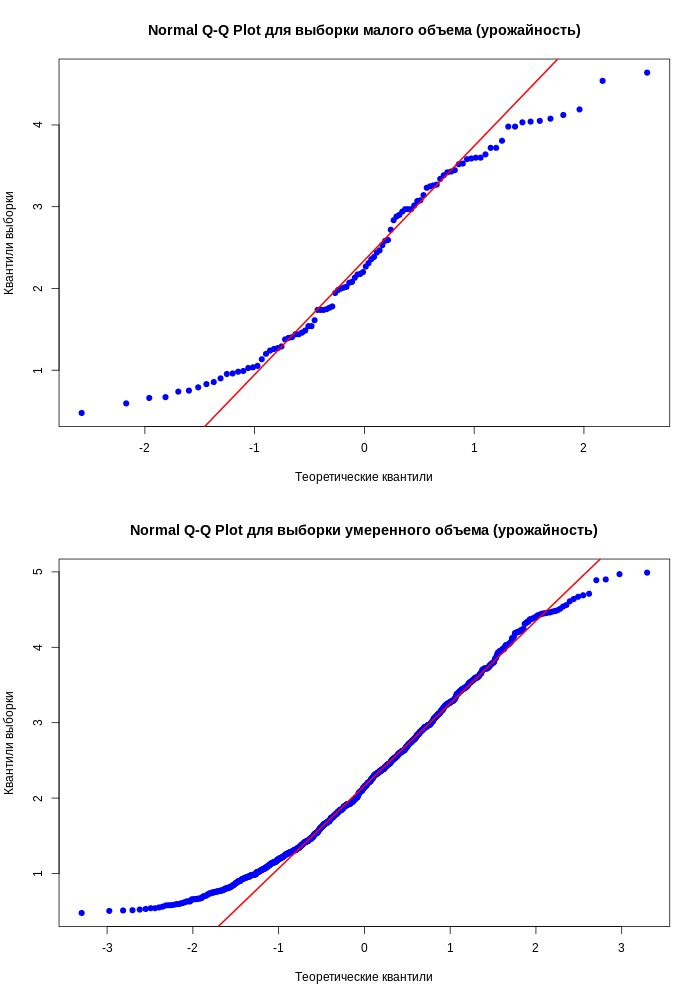

In [ ]:
%%R  -w 700 -h 1000

par(mfrow = c(2,1))
# QQ-график для маленькой выборки
qqnorm(small_df1r$Crop_Yield_MT_per_HA, main = "Normal Q-Q Plot для выборки малого объема (урожайность)",
       xlab = "Теоретические квантили", ylab = "Квантили выборки", pch = 19, col = "blue")
qqline(small_df1r$Crop_Yield_MT_per_HA, col = "red", lwd = 2)

# QQ-график для полной выборки
qqnorm(df1r$Crop_Yield_MT_per_HA, main = "Normal Q-Q Plot для выборки умеренного объема (урожайность)",
       xlab = "Теоретические квантили", ylab = "Квантили выборки", pch = 19, col = "blue")
qqline(df1r$Crop_Yield_MT_per_HA, col = "red", lwd = 2)
par(mfrow = c(1, 1))

**Метод огибающих**

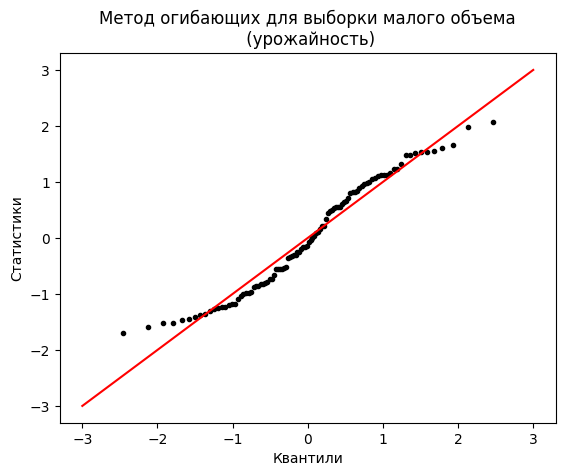

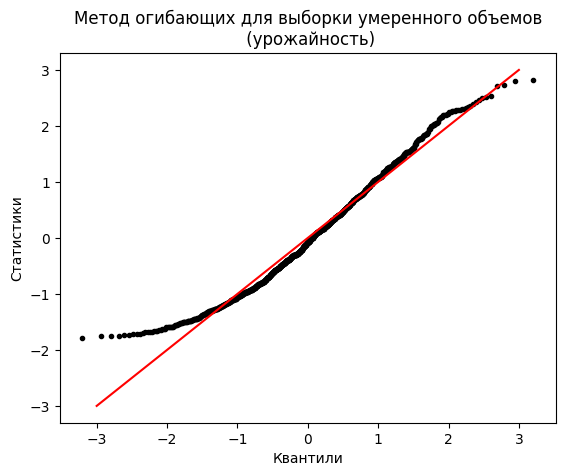

In [ ]:
envelmet(small_df.Crop_Yield_MT_per_HA, 'Метод огибающих для выборки малого объема\n (урожайность)')
plt.show()
envelmet(df1.Crop_Yield_MT_per_HA, 'Метод огибающих для выборки умеренного объемов\n (урожайность)')
plt.show()

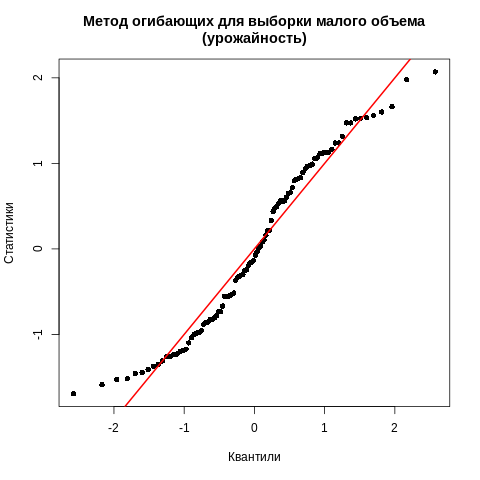

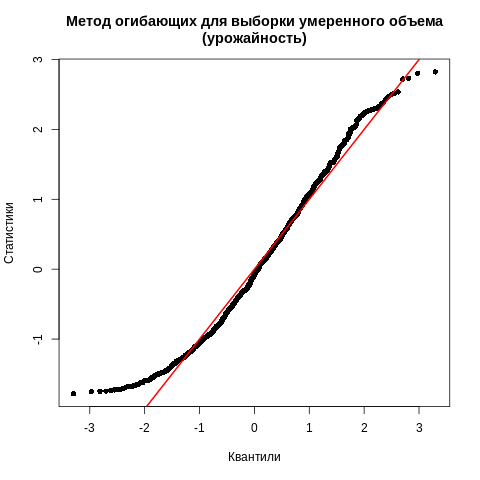

In [ ]:
%%R
envelope_plot(small_df1r$Crop_Yield_MT_per_HA, "Метод огибающих для выборки малого объема\n(урожайность)")
envelope_plot(df1r$Crop_Yield_MT_per_HA, "Метод огибающих для выборки умеренного объема\n(урожайность)")

**Проверка гипотез о нормальности**

In [ ]:
print('Тест Колмогорова-Смирнова')
t1 = 'выборки малого объема'
t2 = 'выборки умеренного объема'
k_s_test(small_df.Crop_Yield_MT_per_HA, t1)
k_s_test(df1.Crop_Yield_MT_per_HA, t2 )

Тест Колмогорова-Смирнова
Тест Колмогорова-Смирнова для выборки малого объема: p-value = 0.3781 => Нет оснований отклонять гипотезу
Тест Колмогорова-Смирнова для выборки умеренного объема: p-value = 0.0033 => Есть основания отклонить гипотезу


In [ ]:
%%R
ks_test(small_df1r$Crop_Yield_MT_per_HA, 'выборки малого объема')
ks_test(df1r$Crop_Yield_MT_per_HA, 'выборки умеренного объема')

Тест Колмогорова-Смирнова для выборки малого объема: p-value = 0.4163 => Нет оснований отклонять гипотезу
Тест Колмогорова-Смирнова для выборки умеренного объема: p-value = 0.0035 => Есть основания отклонить гипотезу


In [ ]:
print('Тест Шапиро-Уилка')
sh_w_test(small_df.Crop_Yield_MT_per_HA, t1)
sh_w_test(df1.Crop_Yield_MT_per_HA, t2)

Тест Шапиро-Уилка
Тест Шапиро-Уилка для выборки малого объема: p-value = 0.0023 => Есть основания отклонить гипотезу
Тест Шапиро-Уилка для выборки умеренного объема: p-value = 0.0000 => Есть основания отклонить гипотезу


In [ ]:
%%R
sh_w_test(small_df1r$Crop_Yield_MT_per_HA, 'выборки малого объема')
sh_w_test(df1r$Crop_Yield_MT_per_HA, 'выборки умеренного объема')

Тест Шапиро-Уилка для выборки малого объема: p-value = 0.0023 => Есть основания отклонить гипотезу
Тест Шапиро-Уилка для выборки умеренного объема: p-value = 0.0000 => Есть основания отклонить гипотезу


In [ ]:
print('Тест Лиллиефорса')
l_test(small_df.Crop_Yield_MT_per_HA, t1)
l_test(df1.Crop_Yield_MT_per_HA, t2)

Тест Лиллиефорса
Тест Лиллиефорса для выборки малого объема: p-value = 0.0541 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для выборки умеренного объема: p-value = 0.0010 => Есть основания отклонить гипотезу


In [ ]:
%%R
l_test(small_df1r$Crop_Yield_MT_per_HA, 'выборки малого объема')
l_test(df1r$Crop_Yield_MT_per_HA, 'выборки умеренного объема')

Тест Лиллиефорса для выборки малого объема: p-value = 0.0525 => Нет оснований отклонять гипотезу
Тест Лиллиефорса для выборки умеренного объема: p-value = 0.0000 => Есть основания отклонить гипотезу


# Второй этап

# Задание 1
Продемонстрировать применение для проверки различных гипотез и
различных доверительных уровней (0.9, 0.95, 0.99) следующих критериев:

a. Стьюдента, включая односторонние варианты, когда
проверяемая нулевая гипотеза заключается в том, что одно из сравниваемых
средних значений больше (или меньше) другого. Реализовать оценку
мощности критериев при заданном объеме выборки или определения
объема выборки для достижения заданной мощности;

b. Уилкоксона-Манна-Уитни (ранговые);

c. Фишера, Левене, Бартлетта, Флигнера-Килина (проверка
гипотез об однородности дисперсий).


---



a. **Критерий Стьюдента**, включая односторонние варианты, когда проверяемая нулевая гипотеза заключается в том, что одно из сравниваемых средних значений больше (или меньше) другого. Реализовать оценку мощности критериев при заданном объеме выборки или определения объема выборки для достижения заданной мощности.

Для применения t-критерия Стьюдента необходимо, чтобы исходные данные имели нормальное распределение и одинаковую дисперсию.

In [ ]:
d1_n01 = np.random.normal(0, 1, size = 100)
d2_n31 = np.random.normal(3, 1, size = 200)
d3_n01 = np.random.normal(0, 1, size = 300)

In [ ]:
%%R
d1r_n01<-  rnorm(100, sd = 1)
d2r_n31 <- rnorm(200, mean = 3, sd = 1)
d3r_n01 <- rnorm(300, sd = 1)

Пусть имеются две независимые выборки объёмами $n_1, n_2$ нормально распределённых случайных величин $X_1, X_2$ с мат. ожиданиями $М1$ и  $М2$.

Нулевая гипотеза $H_0$:

 $М1=М2$ (при использовании параметра alternative = 'two-sided')

  ИЛИ

  $М1<М2$  (при использовании параметра alternative = 'greater').
  
   Гипотеза принимается, если $p\text{-value} > 0.05$, и отвергается, если $p\text{-value} < 0.05$.


In [ ]:
from pingouin import ttest
def t_test(data1, data2, alternative, confidence):
    result = ttest(data1, data2, alternative=alternative, confidence=confidence)
    p_value = result['p-val'][0]
    power = result['power'][0]
    if p_value < (1-confidence):
        decision = "Нулевая гипотеза отвергается"
    else:
        decision = "Нет оснований отвергнуть нулевую гипотезу"
    print(f"Результат теста: {decision}")
    print(f"Мощность критерия: {power:.2f}")
    return result

In [ ]:
%%R
t_test <- function(x, y, alternative, conf.level) {
  cat("Результат теста:")
  if (t.test(x, y, alternative = alternative, conf.level = conf.level)$p.value < (1-conf.level)) {
    cat("Нулевая гипотеза отвергается\n")
  } else {
    cat("Нет оснований отвергнуть нулевую гипотезу\n")
  }
  cat(sprintf("Мощность критерия: %.2f\n", power.t.test(delta = abs(mean(x) - mean(y)),
                                                                    sd = sd(c(x, y)),
                                                                    n = min(length(x), length(y)),
                                                                    sig.level = 0.05)$power))
}


Для гипотезы $H_0$: средние двух выборок равны (при использовании параметра alternative = 'two-sided')

In [ ]:
print( '\td1_n01 и d2_n31')
t_test(d1_n01,d2_n31 ,'two-sided',0.9)
t_test(d1_n01,d2_n31 ,'two-sided',0.95)
t_test(d1_n01,d2_n31 ,'two-sided',0.99)

	d1_n01 и d2_n31
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00


,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-22.976647,186.693178,two-sided,2.598219e-56,"[-3.2940335567435537, -2.623762241408815]",2.878077,1.273e+64,1.0


In [ ]:
print( '\td1_n01 и d3_n01')
t_test(d1_n01,d3_n01 ,'two-sided', 0.9)
t_test(d1_n01,d3_n01 ,'two-sided', 0.95)
t_test(d1_n01,d3_n01 ,'two-sided', 0.99)


	d1_n01 и d3_n01
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.05
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.05
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.05


,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-0.055244,153.828624,two-sided,0.956016,"[-0.32123037805237586, 0.30790466295072]",0.006784,0.127,0.050394


In [ ]:
print( '\td2_n31 и d3_n01')
t_test(d2_n31,d3_n01 ,'two-sided', confidence = 0.9)
t_test(d2_n31,d3_n01 ,'two-sided', confidence = 0.95)
t_test(d2_n31,d3_n01 ,'two-sided', confidence = 0.99)

	d2_n01 и d3_n01
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00


,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,32.906562,409.972045,two-sided,4.129753e-117,"[2.7200620915892206, 3.184407991461491]",3.037829,7.92e+122,1.0


In [ ]:
%%R
cat("Тест d1r_n01 и d2r_n31:\n")
t_test(d1r_n01, d2r_n31, alternative = "two.sided", conf.level = 0.9)
t_test(d1r_n01, d2r_n31, alternative = "two.sided", conf.level = 0.95)
t_test(d1r_n01, d2r_n31, alternative = "two.sided", conf.level = 0.99)

cat("\nТест d1r_n01 и d3r_n01:\n")
t_test(d1r_n01, d3r_n01, alternative = "two.sided", conf.level = 0.9)
t_test(d1r_n01, d3r_n01, alternative = "two.sided", conf.level = 0.95)
t_test(d1r_n01, d3r_n01, alternative = "two.sided", conf.level = 0.99)

cat("\nТест d2r_n31 и d3r_n01:\n")
t_test(d2r_n31, d3r_n01, alternative = "two.sided", conf.level = 0.9)
t_test(d2r_n31, d3r_n01, alternative = "two.sided", conf.level = 0.95)
t_test(d2r_n31, d3r_n01, alternative = "two.sided", conf.level = 0.99)


Тест d1r_n01 и d2r_n31:
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00

Тест d1r_n01 и d3r_n01:
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.11
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.11
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.11

Тест d2r_n31 и d3r_n01:
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00


Для гипотезы  H0 :  M1<M2  (при использовании параметра  alternative = 'greater')

In [ ]:
print( '\td1_n01 и d2_n31')
t_test(d1_n01,d2_n31 , 'greater', confidence = 0.9)
t_test(d1_n01,d2_n31 , 'greater', confidence = 0.95)
t_test(d1_n01,d2_n31 , 'greater', confidence = 0.99)

	d1_n01 и d2_n31
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.00
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.00
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.00


,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-22.976647,186.693178,greater,1.0,"[-3.2610749946287076, inf]",2.878077,3.927e-65,0.0


In [ ]:
print( '\td1_n01 и d3_n01')
t_test(d1_n01,d3_n01 , 'greater', confidence = 0.9)
t_test(d1_n01,d3_n01 , 'greater', confidence = 0.95)
t_test(d1_n01,d3_n01 , 'greater', confidence = 0.99)

	d1_n01 и d3_n01
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.04
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.04
Результат теста: Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.04


,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,-0.055244,153.828624,greater,0.521992,"[-0.2901936690327514, inf]",0.006784,0.255,0.044236


In [ ]:
print( '\td2_n01 и d3_n01')
t_test(d2_n31, d3_n01,  'greater', confidence = 0.9)
t_test(d2_n31, d3_n01,  'greater', confidence = 0.95)
t_test(d2_n31, d3_n01,  'greater', confidence = 0.99)

	d2_n01 и d3_n01
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста: Нулевая гипотеза отвергается
Мощность критерия: 1.00


,T,dof,alternative,p-val,CI99%,cohen-d,BF10,power
T-test,32.906562,409.972045,greater,2.064877e-117,"[2.742706020008425, inf]",3.037829,1.584e+123,1.0


In [ ]:
%%R
cat("Тест d1r_n01 и d2r_n31:\n")
t_test(d1r_n01, d2r_n31, alternative = "greater", conf.level = 0.9)
t_test(d1r_n01, d2r_n31, alternative = "greater", conf.level = 0.95)
t_test(d1r_n01, d2r_n31, alternative = "greater", conf.level = 0.99)

cat("\nТест d1r_n01 и d3r_n01:\n")
t_test(d1r_n01, d3r_n01, alternative = "greater", conf.level = 0.9)
t_test(d1r_n01, d3r_n01, alternative = "greater", conf.level = 0.95)
t_test(d1r_n01, d3r_n01, alternative = "greater", conf.level = 0.99)

cat("\nТест d2r_n31 и d3r_n01:\n")
t_test(d2r_n31, d3r_n01, alternative = "greater", conf.level = 0.9)
t_test(d2r_n31, d3r_n01, alternative = "greater", conf.level = 0.95)
t_test(d2r_n31, d3r_n01, alternative = "greater", conf.level = 0.99)

Тест d1r_n01 и d2r_n31:
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 1.00
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 1.00
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 1.00

Тест d1r_n01 и d3r_n01:
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.12
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.12
Результат теста:Нет оснований отвергнуть нулевую гипотезу
Мощность критерия: 0.12

Тест d2r_n31 и d3r_n01:
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00
Результат теста:Нулевая гипотеза отвергается
Мощность критерия: 1.00


b. **Критерий Уилкоксона-Манна-Уитни** (ранговые);

Ранговый критерий Манна и Уитни основан на критерии Уилкоксона для независимых выборок. Он является непараметрическим аналогом t-критерия для сравнения двух средних значений распределений.

Асимптотическая эффективность U-критерия равна 0.95.
U-критерий Уилкоксона, Манна и Уитни проверяет гипотезу о принадлежности двух выборок одной и той же генеральной совокупности. Эта гипотеза включает также равенство значений медиан  и равенство средних значений .

In [ ]:
from scipy.stats import mannwhitneyu
np.random.seed(1)
d1 = np.random.poisson(5, 10)
d2 = np.random.poisson(5, 20)
d3 = np.random.poisson(10, 30)
print(' Cредние для d1, d2 и d3:')
print(d1.mean())
print(d2.mean())
print(d3.mean())

print('\nРезультаты для d1 и d2')
print('M1 = M2 ', mannwhitneyu(d1, d2, alternative='two-sided'))
print('M1 < M2 ', mannwhitneyu(d1, d2, alternative='greater'))


print('\nРезультаты для d1 и d3')
print('M1 = M3 ', mannwhitneyu(d1, d3, alternative='two-sided'))
print('M1 < M3 ', mannwhitneyu(d1, d3, alternative='greater'))

print('\nРезультаты для d2 и d3')
print('M2 = M3 ', mannwhitneyu(d2, d3, alternative='two-sided'))
print('M2 < M3 ', mannwhitneyu(d2, d3, alternative='greater'))

 Cредние для d1, d2 и d3:
4.1
5.0
11.0

Результаты для d1 и d2
M1 = M2  MannwhitneyuResult(statistic=71.0, pvalue=0.19996561624078668)
M1 < M2  MannwhitneyuResult(statistic=71.0, pvalue=0.9076827406115716)

Результаты для d1 и d3
M1 = M3  MannwhitneyuResult(statistic=8.0, pvalue=9.210271900836144e-06)
M1 < M3  MannwhitneyuResult(statistic=8.0, pvalue=0.9999960202624639)

Результаты для d2 и d3
M2 = M3  MannwhitneyuResult(statistic=39.0, pvalue=2.1167631611527568e-07)
M2 < M3  MannwhitneyuResult(statistic=39.0, pvalue=0.9999999049150953)


In [ ]:
%%R
ch <- function(x, conf.level) {
  if (x < (1-conf.level)) {
    return("Нулевая гипотеза отвергается")
  } else {
    return("Нет оснований отвергнуть нулевую гипотезу")
  }
}
set.seed(1)

d1 <- rpois(10, lambda = 5)
d2 <- rpois(10, lambda = 5)
d3 <- rpois(10, lambda = 10)

cat("Средние для d1, d2 и d3:\n")
cat("d1 mean:", mean(d1), "\n")
cat("d2 mean:", mean(d2), "\n")
cat("d3 mean:", mean(d3), "\n\n")

cat("\nРезультаты для d1 и d2:\n")
res = wilcox.test(d1, d2, alternative = "two.sided", conf.level = 0.9)$p.value
cat("M1 = M2\n 0.9  p.val =", res, "\n")
cat("0.95  p.val =", wilcox.test(d1, d2, alternative = "two.sided", conf.level = 0.95)$p.value, "\n")
cat("0.99  p.val =", wilcox.test(d1, d2, alternative = "two.sided", conf.level = 0.99)$p.value, "\n")
cat("M1 < M2\n")
cat(" 0.9  p.val =", wilcox.test(d1, d2, alternative = "less", conf.level = 0.9)$p.value, "\n")
cat("0.95  p.val =", wilcox.test(d1, d2, alternative = "less", conf.level = 0.95)$p.value, "\n")
cat("0.99  p.val =", wilcox.test(d1, d2, alternative = "less", conf.level = 0.99)$p.value, "\n\n")

cat("\nРезультаты для d1 и d3:\n")
cat("M1 = M3\n")
cat(" 0.9  p.val =", wilcox.test(d1, d3, alternative = "two.sided", conf.level = 0.9)$p.value, "\n")
cat("0.95  p.val =", wilcox.test(d1, d3, alternative = "two.sided", conf.level = 0.95)$p.value, "\n")
cat("0.99  p.val =", wilcox.test(d1, d3, alternative = "two.sided", conf.level = 0.99)$p.value, "\n")
cat("M1 < M3\n")
cat(" 0.9  p.val =", wilcox.test(d1, d3, alternative = "greater", conf.level = 0.9)$p.value, "\n")
cat("0.95  p.val =", wilcox.test(d1, d3, alternative = "greater", conf.level = 0.95)$p.value, "\n")
cat("0.99  p.val =", wilcox.test(d1, d3, alternative = "greater", conf.level = 0.99)$p.value, "\n\n")

cat("\nРезультаты для d2 и d3:\n")
cat("M1 = M3\n")
cat(" 0.9  p.val =", wilcox.test(d2, d3, alternative = "two.sided", conf.level = 0.9)$p.value, "\n")
cat("0.95  p.val =", wilcox.test(d2, d3, alternative = "two.sided", conf.level = 0.95)$p.value, "\n")
cat("0.99  p.val =", wilcox.test(d2, d3, alternative = "two.sided", conf.level = 0.99)$p.value, "\n")
cat("M1 < M3\n")
cat(" 0.9  p.val =", wilcox.test(d2, d3, alternative = "greater", conf.level = 0.9)$p.value, "\n")
cat("0.95  p.val =", wilcox.test(d2, d3, alternative = "greater", conf.level = 0.95)$p.value, "\n")
cat("0.99  p.val =", wilcox.test(d2, d3, alternative = "greater", conf.level = 0.99)$p.value, "\n\n")


Средние для d1, d2 и d3:
d1 mean: 5.5 
d2 mean: 5.6 
d3 mean: 9.5 


Результаты для d1 и d2:
M1 = M2
 0.9  p.val = 1 
0.95  p.val = 1 
0.99  p.val = 1 
M1 < M2
 0.9  p.val = 0.5304385 
0.95  p.val = 0.5304385 
0.99  p.val = 0.5304385 


Результаты для d1 и d3:
M1 = M3
 0.9  p.val = 0.01211583 
0.95  p.val = 0.01211583 
0.99  p.val = 0.01211583 
M1 < M3
 0.9  p.val = 0.9951279 
0.95  p.val = 0.9951279 
0.99  p.val = 0.9951279 


Результаты для d2 и d3:
M1 = M3
 0.9  p.val = 0.01093311 
0.95  p.val = 0.01093311 
0.99  p.val = 0.01093311 
M1 < M3
 0.9  p.val = 0.9956137 
0.95  p.val = 0.9956137 
0.99  p.val = 0.9956137 



c. **Критерии Фишера, Левене, Бартлетта, Флигнера-Килина (проверка гипотез об однородности дисперсий).**

Даны выборки
X1,…,Xn∼N(μ1,σ1) и Y1,…,Ym∼N(μ2,σ2).

Нулевая гипотеза \$$H_0$ : $DX = DY$.

In [ ]:
# Критерий Фишера
from scipy.stats import f

def f_test(sample1, sample2, alternative='two-sided'):
    var1 = sample1.var(ddof=1)
    var2 = sample2.var(ddof=1)
    n1 = len(sample1)
    n2 = len(sample2)
    f_stat = var1 / var2 if var1 >= var2 else var2 / var1
    dfn = n1 - 1
    dfd = n2 - 1
    p_value = 2 * min(f.cdf(f_stat, dfn, dfd), 1 - f.cdf(f_stat, dfn, dfd))
    return f_stat, p_value

print('Критерий Фишера для d1_n01 и d2_n31')
f_stat, p_value = f_test(d1_n01, d2_n31)
print(f"F-статистика: {f_stat}")
print(f"P-значение: {p_value}")


print('\nКритерий Фишера для d1_n01 и d3_n01')
f_stat, p_value = f_test(d1_n01, d3_n01)
print(f"F-статистика: {f_stat}")
print(f"P-значение: {p_value}")


d4_n53 = np.random.normal(5, 3, size=30)
print('\nКритерий Фишера для d1_n01 и d4_n53')
f_stat, p_value = f_test(d1_n01, d4_n53)
print(f"F-статистика: {f_stat}")
print(f"P-значение: {p_value}")


Критерий Фишера для d1_n01 и d2_n31
F-статистика: 1.1441908623927108
P-значение: 0.4247942332798975

Критерий Фишера для d1_n01 и d3_n01
F-статистика: 1.279859267803078
P-значение: 0.11871554058299094

Критерий Фишера для d1_n01 и d4_n53
F-статистика: 4.758995814576548
P-значение: 1.0873446723236313e-05


In [ ]:
%%R
cat('Критерий Фишера для d1r_n01 и d2r_n31')
res = var.test(d1r_n01, d2r_n31, alternative = "two.sided", conf.level = 0.9)
cat("\n 0.9:  pvalue =", res$p.value, '\n')
res = var.test(d1r_n01, d2r_n31, alternative = "two.sided", conf.level = 0.95)
cat("0.95:  pvalue =", res$p.value, '\n')
res = var.test(d1r_n01, d2r_n31, alternative = "two.sided", conf.level = 0.99)
cat("0.99:  pvalue =", res$p.value, '\n')

cat('Критерий Фишера для d1r_n01 и d3r_n01')
res = var.test(d1r_n01, d3r_n01, alternative = "two.sided", conf.level = 0.9)
cat("\n 0.9:  pvalue =", res$p.value, '\n')
res = var.test(d1r_n01, d3r_n01, alternative = "two.sided", conf.level = 0.95)
cat("0.95:  pvalue =", res$p.value, '\n')
res = var.test(d1r_n01, d3r_n01, alternative = "two.sided", conf.level = 0.99)
cat("0.99:  pvalue =", res$p.value, '\n')

d4r_n53 <- rnorm(300, mean= 5, sd = 3)
cat('Критерий Фишера для d1r_n01 и d4r_n53')
res = var.test(d1r_n01, d4r_n53, alternative = "two.sided", conf.level = 0.9)
cat("\n 0.9:  pvalue =", res$p.value, '\n')
res = var.test(d1r_n01, d4r_n53, alternative = "two.sided", conf.level = 0.95)
cat(" 0.95:  pvalue =", res$p.value, '\n')
res = var.test(d1r_n01, d4r_n53, alternative = "two.sided", conf.level = 0.95)
cat(" 0.99:  pvalue =", res$p.value, '\n')

Критерий Фишера для d1r_n01 и d2r_n31
 0.9:  pvalue = 0.3998778 
0.95:  pvalue = 0.3998778 
0.99:  pvalue = 0.3998778 
Критерий Фишера для d1r_n01 и d3r_n01
 0.9:  pvalue = 0.2547641 
0.95:  pvalue = 0.2547641 
0.99:  pvalue = 0.2547641 
Критерий Фишера для d1r_n01 и d4r_n53
 0.9:  pvalue = 1.356926e-26 
 0.95:  pvalue = 1.356926e-26 
 0.99:  pvalue = 1.356926e-26 


Так как для критерия Левене нужны выборки необязательно из нормального распределения, то можно рассмотреть дисперсии температуры в России, США и Канаде.

In [ ]:
from scipy.stats import levene
from scipy.stats import bartlett
from scipy.stats import fligner
#Критерий Левене
d1 = df1[df1['Country']=='Russia'].Average_Temperature_C
d2 = df1[df1['Country']=='USA'].Average_Temperature_C
d3 = df1[df1['Country']=='China'].Average_Temperature_C

print('Дисперсии: ', d1.var(), d2.var(), d3.var())
print('Критерий Левене для d1 и d2')
print(levene(d1, d2))

print('\nКритерий Левене для d1 и d3')
print(levene(d1, d3))

print('\nКритерий Левене для d2 и d3')
print(levene(d2, d3))


Дисперсии:  145.9163168714169 144.82002725643898 109.47450112201967
Критерий Левене для d1 и d2
LeveneResult(statistic=0.06480855410303195, pvalue=0.7993076216588967)

Критерий Левене для d1 и d3
LeveneResult(statistic=4.178808038100097, pvalue=0.04222997089309055)

Критерий Левене для d2 и d3
LeveneResult(statistic=5.400785391359515, pvalue=0.02120818877757362)


In [ ]:
%%R
install.packages("car")
library(car)

In [ ]:
%%R

d1 <- subset(df1r, Country == "Russia")$Average_Temperature_C
d2 <- subset(df1r, Country == "USA")$Average_Temperature_C
d3 <- subset(df1r, Country == "China")$Average_Temperature_C

cat("Дисперсии:\n",  var(d1), var(d2),var(d3),'\n')

# Критерий Левене
cat("Критерий Левене для d1 и d2:\n")
print(leveneTest(c(d1, d2), group = c(rep("d1", length(d1)), rep("d2", length(d2)))))

cat("\nКритерий Левене для d1 и d3:\n")
print(leveneTest(c(d1, d3), group = c(rep("d1", length(d1)), rep("d3", length(d3)))))

cat("\nКритерий Левене для d2 и d3:\n")
print(leveneTest(c(d2, d3), group = c(rep("d2", length(d2)), rep("d3", length(d3)))))


Дисперсии:
 145.9163 144.82 109.4745 
Критерий Левене для d1 и d2:
Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   1  0.0648 0.7993
      204               

Критерий Левене для d1 и d3:
Levene's Test for Homogeneity of Variance (center = median)
       Df F value  Pr(>F)  
group   1  4.1788 0.04223 *
      202                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Критерий Левене для d2 и d3:
Levene's Test for Homogeneity of Variance (center = median)
       Df F value  Pr(>F)  
group   1  5.4008 0.02121 *
      186                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


 Можно заметить, что для d1 и d2 p-value > 0,05.Таким образом, у нас недостаточно доказательств, чтобы отвергнуть нулевую гипотезу о равенстве дисперсий температуры в России и США.

 Однако для d1 и d3  p-value < 0,05, для d2 и d3 p-value < 0,05, значит есть основания отвергнуть нулевые гипотезы о равенстве дисперсий.

In [ ]:
#Критерий Бартлетта
print('Критерий  Бартлетта для d1_n01 и d2_n31')
print(bartlett(d1_n01, d2_n31))

print('\nКритерий  Бартлетта для d1_n01 и d3_n01')
print(bartlett(d1_n01, d3_n01))

print('\nКритерий  Бартлетта для d1_n01 и d4_53')
print(bartlett(d1_n01, d4_n53))


Критерий  Бартлетта для d1_n01 и d2_n31
BartlettResult(statistic=0.6060837979565555, pvalue=0.4362661512113295)

Критерий  Бартлетта для d1_n01 и d3_n01
BartlettResult(statistic=2.3474368005815576, pvalue=0.12548919346290854)

Критерий  Бартлетта для d1_n01 и d4_53
BartlettResult(statistic=33.209582893571444, pvalue=8.274176326106672e-09)


In [ ]:
%%R
# Критерий Бартлетта для d1_n01 и d2_n31
cat("Критерий Бартлетта для d1_n01 и d2_n31:\n")
print(bartlett.test(list(d1r_n01, d2r_n31)))

# Критерий Бартлетта для d1_n01 и d3_n01
cat("\nКритерий Бартлетта для d1_n01 и d3_n01:\n")
print(bartlett.test(list(d1r_n01, d3r_n01)))

# Критерий Бартлетта для d1_n01 и d4_n53
cat("\nКритерий Бартлетта для d1_n01 и d4_n53:\n")
print(bartlett.test(list(d1r_n01, d4r_n53)))

Критерий Бартлетта для d1_n01 и d2_n31:

	Bartlett test of homogeneity of variances

data:  list(d1r_n01, d2r_n31)
Bartlett's K-squared = 0.67604, df = 1, p-value = 0.411


Критерий Бартлетта для d1_n01 и d3_n01:

	Bartlett test of homogeneity of variances

data:  list(d1r_n01, d3r_n01)
Bartlett's K-squared = 1.2342, df = 1, p-value = 0.2666


Критерий Бартлетта для d1_n01 и d4_n53:

	Bartlett test of homogeneity of variances

data:  list(d1r_n01, d4r_n53)
Bartlett's K-squared = 114.38, df = 1, p-value < 2.2e-16



Так как для критерия Флингера-Килина нужны выборки необязательно из нормального распределения, то можно рассмотреть дисперсии температуры в России, США и Канаде.

In [ ]:
#Критерий Флингера-Килина
print('Критерий Флингера-Килинадля d1 и d2')
print(fligner(d1, d2))

print('\nКритерий Флингера-Килина для d1 и d3')
print(fligner(d1, d3))

print('\nКритерий Флингера-Килина для d1 и d2')
print(fligner(d1, d3))


Критерий Флингера-Килинадля d1 и d2
FlignerResult(statistic=0.08635329518471019, pvalue=0.7688654104592894)

Критерий Флингера-Килина для d1 и d3
FlignerResult(statistic=5.285103220717803, pvalue=0.021508617159549746)

Критерий Флингера-Килина для d1 и d2
FlignerResult(statistic=5.285103220717803, pvalue=0.021508617159549746)


# Задание 2

*Исследовать корреляционные взаимосвязи в данных с помощью
коэффициентов корреляции Пирсона, Спирмена и Кендалла.*

**Коэффициент корреляции Пирсона**

In [ ]:
from scipy.stats import pearsonr

print('Урожайность vs Температура:', pearsonr(df1['Crop_Yield_MT_per_HA'], df1['Average_Temperature_C']))
print('Урожайность vs Экстремальные погодные события:',pearsonr(df1['Crop_Yield_MT_per_HA'], df1['Extreme_Weather_Events']))
print('Урожайность vs Доход:',pearsonr(df1['Crop_Yield_MT_per_HA'], df1['Economic_Impact_Million_USD']))

Урожайность vs Температура: PearsonRResult(statistic=0.2270592125749195, pvalue=2.0412235411911182e-13)
Урожайность vs Экстремальные погодные события: PearsonRResult(statistic=-0.07766632326935784, pvalue=0.01300589620639698)
Урожайность vs Доход: PearsonRResult(statistic=0.7104686351410643, pvalue=7.925858203902724e-158)


In [ ]:
%%R
cat("Урожайность vs Температура:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Average_Temperature_C, method = "pearson"))
cat("\nУрожайность vs Экстремальные погодные события:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Extreme_Weather_Events, method = "pearson"))
cat("\nУрожайность vs Доход:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Economic_Impact_Million_USD, method = "pearson"))

Урожайность vs Температура:

	Pearson's product-moment correlation

data:  df1r$Crop_Yield_MT_per_HA and df1r$Average_Temperature_C
t = 7.4462, df = 1020, p-value = 2.041e-13
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1680776 0.2844209
sample estimates:
      cor 
0.2270592 


Урожайность vs Экстремальные погодные события:

	Pearson's product-moment correlation

data:  df1r$Crop_Yield_MT_per_HA and df1r$Extreme_Weather_Events
t = -2.488, df = 1020, p-value = 0.01301
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.13832943 -0.01642262
sample estimates:
        cor 
-0.07766632 


Урожайность vs Доход:

	Pearson's product-moment correlation

data:  df1r$Crop_Yield_MT_per_HA and df1r$Economic_Impact_Million_USD
t = 32.243, df = 1020, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6787166 0.7395695
sample estimates:
      cor 
0.

**Коэффициент корреляции Спирмена**

In [ ]:
from scipy.stats import spearmanr

print('Урожайность vs Температура:', spearmanr(df1['Crop_Yield_MT_per_HA'], df1['Average_Temperature_C']))
print('\nУрожайность vs Экстремальные погодные события:', spearmanr(df1['Crop_Yield_MT_per_HA'], df1['Extreme_Weather_Events']))
print('\nУрожайность vs Доход:', spearmanr(df1['Crop_Yield_MT_per_HA'], df1['Economic_Impact_Million_USD']))

Урожайность vs Температура: SignificanceResult(statistic=0.24094956380433996, pvalue=5.775595174776304e-15)
Урожайность vs Экстремальные погодные события: SignificanceResult(statistic=-0.07604492409979141, pvalue=0.01503202634711808)
Урожайность vs Доход: SignificanceResult(statistic=0.7007761028193145, pvalue=8.70280443840517e-152)


In [ ]:
%%R
cat("Урожайность vs Температура:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Average_Temperature_C, method = "spearman"))

cat("\nУрожайность vs Экстремальные погодные события:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Extreme_Weather_Events, method = "spearman"))

cat("\nУрожайность vs Доход:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Economic_Impact_Million_USD, method = "spearman"))

Урожайность vs Температура:

	Spearman's rank correlation rho

data:  df1r$Crop_Yield_MT_per_HA and df1r$Average_Temperature_C
S = 135047926, p-value = 5.819e-15
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.2409211 


Урожайность vs Экстремальные погодные события:

	Spearman's rank correlation rho

data:  df1r$Crop_Yield_MT_per_HA and df1r$Extreme_Weather_Events
S = 191446331, p-value = 0.01498
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.07608363 


Урожайность vs Доход:

	Spearman's rank correlation rho

data:  df1r$Crop_Yield_MT_per_HA and df1r$Economic_Impact_Million_USD
S = 53235634, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7007726 



**Коэффициент корреляции Кендалла**

In [ ]:
from scipy.stats import kendalltau

print('Урожайность vs Температура:', kendalltau(df1['Crop_Yield_MT_per_HA'], df1['Average_Temperature_C']))
print('\nУрожайность vs Экстремальные погодные события:',kendalltau(df1['Crop_Yield_MT_per_HA'], df1['Extreme_Weather_Events']))
print('\nУрожайность vs Доход:', kendalltau(df1['Crop_Yield_MT_per_HA'], df1['Economic_Impact_Million_USD']))

Урожайность vs Температура: SignificanceResult(statistic=0.1568549562721149, pvalue=6.290688589253831e-14)

Урожайность vs Экстремальные погодные события: SignificanceResult(statistic=-0.052751057058635406, pvalue=0.015692808280768578)

Урожайность vs Доход: SignificanceResult(statistic=0.5165325841541547, pvalue=8.968331170629392e-135)


In [ ]:
%%R
cat("Урожайность vs Температура:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Average_Temperature_C, method = "kendall"))

cat("\nУрожайность vs Экстремальные погодные события:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Extreme_Weather_Events, method = "kendall"))

cat("\nУрожайность vs Доход:\n")
print(cor.test(df1r$Crop_Yield_MT_per_HA, df1r$Economic_Impact_Million_USD, method = "kendall"))

Урожайность vs Температура:

	Kendall's rank correlation tau

data:  df1r$Crop_Yield_MT_per_HA and df1r$Average_Temperature_C
z = 7.5008, p-value = 6.343e-14
alternative hypothesis: true tau is not equal to 0
sample estimates:
      tau 
0.1568298 


Урожайность vs Экстремальные погодные события:

	Kendall's rank correlation tau

data:  df1r$Crop_Yield_MT_per_HA and df1r$Extreme_Weather_Events
z = -2.4175, p-value = 0.01563
alternative hypothesis: true tau is not equal to 0
sample estimates:
       tau 
-0.0527839 


Урожайность vs Доход:

	Kendall's rank correlation tau

data:  df1r$Crop_Yield_MT_per_HA and df1r$Economic_Impact_Million_USD
z = 24.706, p-value < 2.2e-16
alternative hypothesis: true tau is not equal to 0
sample estimates:
      tau 
0.5165058 



# Задание 3
*Продемонстрировать использование методов хи-квадрат, точного
теста Фишера, теста МакНемара, Кохрана-Мантеля-Хензеля.*

**Тест χ2**

Критерий Пирсона, также известный как χ² (хи-квадрат) тест, является статистическим методом, используемым для проверки гипотез о независимости двух признаках.

\$$H_0$: X и Y независимы.

In [ ]:
from scipy.stats import chi2_contingency
c_table = pd.crosstab(df1['Country'], df1['Adaptation_Strategies'])
chi2, p, dof, expected = chi2_contingency(c_table)
print(f"χ²: {chi2}, p-value: {p}")
c_table


χ²: 41.12162214511037, p-value: 0.25626257445972495


Adaptation_Strategies,Crop Rotation,Drought-resistant Crops,No Adaptation,Organic Farming,Water Management
Country,,,,,
Argentina,18,19,20,23,27
Australia,25,23,19,18,28
Brazil,24,24,25,16,22
Canada,25,23,22,12,17
China,24,15,28,12,14
France,18,25,14,13,17
India,13,13,24,22,23
Nigeria,24,23,31,18,15
Russia,30,18,19,24,20


In [ ]:
c_table = pd.crosstab(df1['Country'], df1['Extreme_Weather_Events'])
chi2, p, dof, expected = chi2_contingency(c_table)
print(f"χ²: {chi2}, p-value: {p}")
c_table

χ²: 81.12199633021297, p-value: 0.7371858674295534


Extreme_Weather_Events,0,1,2,3,4,5,6,7,8,9,10
Country,,,,,,,,,,,
Argentina,14,7,9,8,7,10,9,11,12,7,13
Australia,8,18,9,9,10,8,11,10,8,9,13
Brazil,13,13,14,7,6,4,15,10,9,6,14
Canada,9,11,8,7,8,9,11,8,6,10,12
China,8,5,5,13,10,10,13,11,6,6,6
France,8,6,5,12,8,8,12,6,6,6,10
India,8,6,11,8,11,5,10,9,9,11,7
Nigeria,7,17,12,8,10,11,14,4,7,13,8
Russia,10,12,10,10,14,13,11,13,2,5,11


In [ ]:
%%R
con_table <- table(df1r$Country, df1r$Adaptation_Strategies)
chi2_test <- chisq.test(con_table)
cat("χ²:", chi2_test$statistic, ", p-value:", chi2_test$p.value, "\n")
print(con_table)

χ²: 41.12162 , p-value: 0.2562626 
           
            Crop Rotation Drought-resistant Crops No Adaptation Organic Farming
  Argentina            18                      19            20              23
  Australia            25                      23            19              18
  Brazil               24                      24            25              16
  Canada               25                      23            22              12
  China                24                      15            28              12
  France               18                      25            14              13
  India                13                      13            24              22
  Nigeria              24                      23            31              18
  Russia               30                      18            19              24
  USA                  16                      21            23              16
           
            Water Management
  Argentina               27
  A

In [ ]:
%%R
con_table <- table(df1r$Country, df1r$Extreme_Weather_Events)
chi2_test <- chisq.test(con_table)
cat("χ²:", chi2_test$statistic, ", p-value:", chi2_test$p.value, "\n")
print(con_table)

χ²: 81.122 , p-value: 0.7371859 
           
             0  1  2  3  4  5  6  7  8  9 10
  Argentina 14  7  9  8  7 10  9 11 12  7 13
  Australia  8 18  9  9 10  8 11 10  8  9 13
  Brazil    13 13 14  7  6  4 15 10  9  6 14
  Canada     9 11  8  7  8  9 11  8  6 10 12
  China      8  5  5 13 10 10 13 11  6  6  6
  France     8  6  5 12  8  8 12  6  6  6 10
  India      8  6 11  8 11  5 10  9  9 11  7
  Nigeria    7 17 12  8 10 11 14  4  7 13  8
  Russia    10 12 10 10 14 13 11 13  2  5 11
  USA       12  8  4  6 10 11  7  7  7 13 10


**Точный тест Фишера**

Точный тест Фишера используется, для проверки наличия связи между двумя категориальными признаками (X и Y), каждый из которых принимает по 2 значения.

\$$H_0$ : X и Y независимы.

In [ ]:
from scipy.stats import fisher_exact
Russia_Prec = df1[df1['Country'] == 'Russia'].Total_Precipitation_mm.mean()
Canada_Prec = df1[df1['Country'] == 'Canada'].Total_Precipitation_mm.mean()

Russia_Pest = df1[df1['Country'] == 'Russia'].Pesticide_Use_KG_per_HA.mean()
Canada_Pest = df1[df1['Country'] == 'Canada'].Total_Precipitation_mm.mean()

Russia_crop = df1[df1['Country'] == 'Russia'].Crop_Yield_MT_per_HA.mean()
Canada_crop = df1[df1['Country'] == 'Canada'].Crop_Yield_MT_per_HA.mean()

print("\tРезультаты для первой таблицы (осадки и урожайность):\n")
tab1 = [[Russia_Prec, Canada_Prec], [Russia_crop, Canada_crop]]
print(tab1)
print(fisher_exact(tab1), '\n')

print("\tРезультаты для второй таблицы (пестициды и урожайность):\n")
tab2 = [[Russia_Pest, Canada_Pest], [Russia_crop, Canada_crop]]
print(tab2)
print(fisher_exact(tab2))


	Результаты для первой таблицы (осадки и урожайность):

[[1639.346126126126, 1622.3380808080806], [2.0714594594594598, 2.3704242424242423]]
SignificanceResult(statistic=1.0104808877928484, pvalue=1.0) 

	Результаты для второй таблицы (пестициды и урожайность):

[[24.089279279279282, 1622.3380808080806], [2.0714594594594598, 2.3704242424242423]]
SignificanceResult(statistic=0.014796547472256474, pvalue=0.0014056888168854124)


In [ ]:
%%R
Russia_Prec <- mean(df1r[df1r$Country == "Russia", "Total_Precipitation_mm"])
Canada_Prec <- mean(df1r[df1r$Country == "Canada", "Total_Precipitation_mm"])

Russia_Pest <- mean(df1r[df1r$Country == "Russia", "Pesticide_Use_KG_per_HA"])
Canada_Pest <- mean(df1r[df1r$Country == "Canada", "Pesticide_Use_KG_per_HA"])

Russia_Crop <- mean(df1r[df1r$Country == "Russia", "Crop_Yield_MT_per_HA"])
Canada_Crop <- mean(df1r[df1r$Country == "Canada", "Crop_Yield_MT_per_HA"])

tab1 <- matrix(c(Russia_Prec, Canada_Prec, Russia_Crop, Canada_Crop), nrow = 2,byrow = TRUE)
tab2 <- matrix(c(Russia_Pest, Canada_Pest, Russia_Crop, Canada_Crop), nrow = 2, byrow = TRUE)

cat("Результаты для первой таблицы (осадки и урожайность):\n")
print(tab1)
fisher_test1 <- fisher.test(tab1)
print(fisher_test1)

cat("\nРезультаты для второй таблицы (пестициды и урожайность):\n")
print(tab2)
fisher_test2 <- fisher.test(tab2)
print(fisher_test2)

Результаты для первой таблицы (осадки и урожайность):
            [,1]        [,2]
[1,] 1639.346126 1622.338081
[2,]    2.071459    2.370424

	Fisher's Exact Test for Count Data

data:  tab1
p-value = 1
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.07318565 13.95172096
sample estimates:
odds ratio 
  1.010479 


Результаты для второй таблицы (пестициды и урожайность):
          [,1]      [,2]
[1,] 24.089279 21.036667
[2,]  2.071459  2.370424

	Fisher's Exact Test for Count Data

data:  tab2
p-value = 1
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  0.07639093 17.00870012
sample estimates:
odds ratio 
  1.139737 



# Задание 4
*Проверить наличие мультиколлинеарности в данных с помощью
корреляционной матрицы и фактора инфляции дисперсии.*

**Корреляционная матрица**


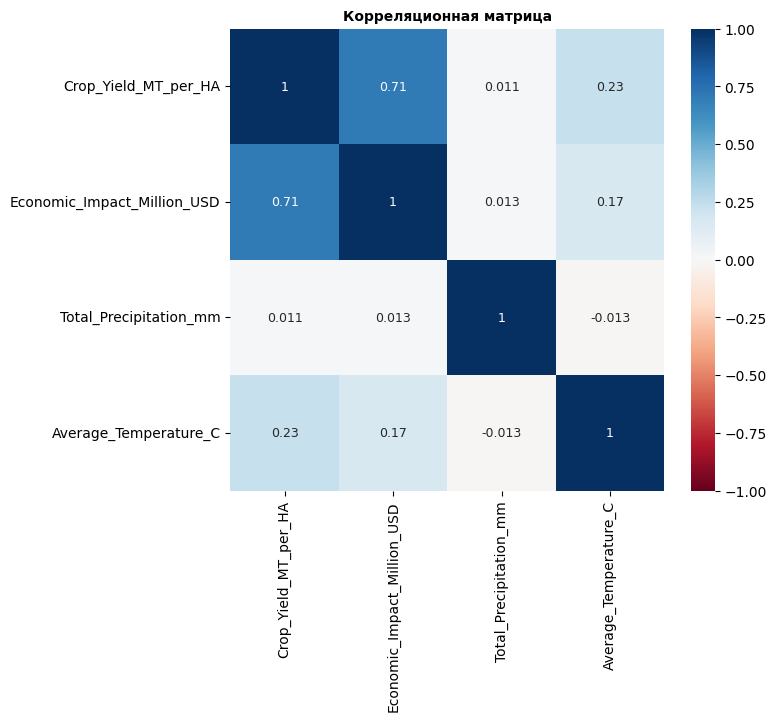

In [ ]:
data1 = df1[['Crop_Yield_MT_per_HA', 'Economic_Impact_Million_USD', 'Total_Precipitation_mm', 'Average_Temperature_C']]

fig = plt.figure(figsize=(7,6))
ax = sns.heatmap(data1.corr(), vmin=-1, vmax=1, cmap='RdBu', annot = True, annot_kws={"fontsize":9})
cbar = ax.collections[0].colorbar
plt.title('Корреляционная матрица', fontsize=10, fontweight='bold')
plt.show()

In [ ]:
%%R
install.packages("corrplot")
library(corrplot)

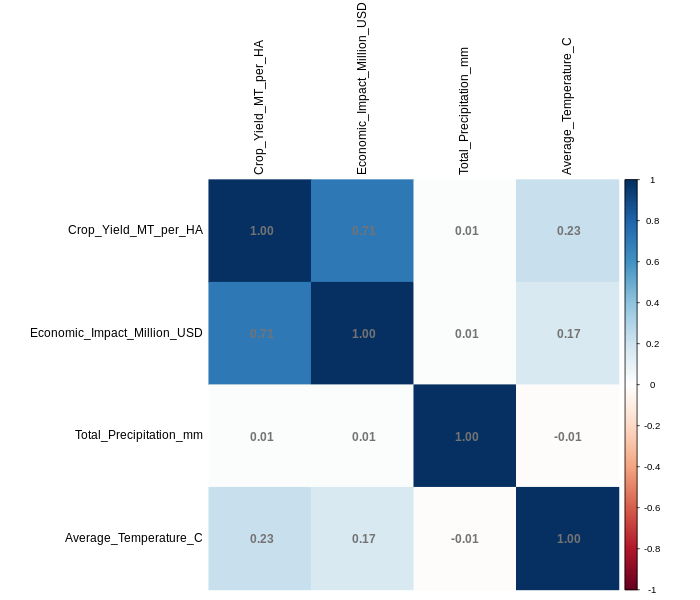

In [ ]:
%%R -w 700 -h 600

data1 <- df1r[c('Crop_Yield_MT_per_HA', 'Economic_Impact_Million_USD', 'Total_Precipitation_mm', 'Average_Temperature_C')]

corrplot(cor(data1),
         method = "color",
         tl.col = "black", addCoef.col = "gray45")

**Фактор инфляции дисперсии**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(data1)
ds = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
               index=X.columns)
print(ds)

const                          10.864084
Crop_Yield_MT_per_HA            2.068986
Economic_Impact_Million_USD     2.019549
Total_Precipitation_mm          1.000414
Average_Temperature_C           1.054729
dtype: float64


In [ ]:
%%R
install.packages("car")
library(car)

In [ ]:
%%R
data1$const <- 1


mod <- lm(const ~ Crop_Yield_MT_per_HA + Economic_Impact_Million_USD + Total_Precipitation_mm+Average_Temperature_C , data = data1)
print(vif(mod))

       Crop_Yield_MT_per_HA Economic_Impact_Million_USD 
                   2.068986                    2.019549 
     Total_Precipitation_mm       Average_Temperature_C 
                   1.000414                    1.054729 


Все переменные имеют невысокие значения VIF(ниже 5). Это говорит о том, что мультиколлинеарность в модели отсутствует или минимальна.

# Задание 5
*Исследовать зависимости в данных с помощью дисперсионного
анализа.*

Дисперсионный анализ (ANOVA – Analisis of Variance)  – это анализ изменчивости признака под влиянием каких-либо переменных (факторов).

Рассмотрим влияние фактора с  k уровнями. В соответствии с уровнями фактора выделяем  k подвыборок X1,..., Xk

Нулевая гипотеза $$H_0:E(X1)=⋯=E(Xk),$$

т.е. средние выборок равны между собой (фактор не оказывает значимого влияния).

In [ ]:
from scipy.stats import f_oneway
gr1 = df1.loc[df1.Adaptation_Strategies == 'Water Management'].Crop_Yield_MT_per_HA
gr2 = df1.loc[df1.Adaptation_Strategies == 'Crop Rotation'].Crop_Yield_MT_per_HA
gr3 = df1.loc[df1.Adaptation_Strategies == 'Organic Farming'].Crop_Yield_MT_per_HA
gr4 = df1.loc[df1.Adaptation_Strategies == 'Drought-resistant Crops'].Crop_Yield_MT_per_HA
gr5 = df1.loc[df1.Adaptation_Strategies == 'No Adaptation'].Crop_Yield_MT_per_HA
f_oneway(gr1, gr2, gr3, gr4, gr5)

1.0068793214127385
0.9731625298259091
0.7140472464288092


F_onewayResult(statistic=0.27576547716582095, pvalue=0.8937089410643455)

In [ ]:
%%R
gr1 <- df1r[df1r$Adaptation_Strategies == "Water Management", "Crop_Yield_MT_per_HA"]
gr2 <- df1r[df1r$Adaptation_Strategies == "Crop Rotation", "Crop_Yield_MT_per_HA"]
gr3 <- df1r[df1r$Adaptation_Strategies == "Organic Farming", "Crop_Yield_MT_per_HA"]
gr4 <- df1r[df1r$Adaptation_Strategies == "Drought-resistant Crops", "Crop_Yield_MT_per_HA"]
gr5 <- df1r[df1r$Adaptation_Strategies == "No Adaptation", "Crop_Yield_MT_per_HA"]

groups <- factor(rep(c("Water Management", "Crop Rotation", "Organic Farming", "Drought-resistant Crops", "No Adaptation"),
                     c(length(gr1), length(gr2), length(gr3), length(gr4), length(gr5))))
values <- c(gr1, gr2, gr3, gr4, gr5)

anova_result <- aov(values ~ groups)
summary(anova_result)

              Df Sum Sq Mean Sq F value Pr(>F)
groups         4    1.1  0.2656   0.276  0.894
Residuals   1017  979.5  0.9631               


# Задание 6

Подогнать регрессионные модели (в том числе, нелинейные) к
данным, а также оценить качество подобной аппроксимации.

Воспользуемся линейной регрессии для предсказания дохода, используя все числовые параметры датасета.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df1_numeric = df1.select_dtypes(exclude=['object']).copy()

X = df1_numeric.drop(columns =['Economic_Impact_Million_USD'])
y = df1_numeric['Economic_Impact_Million_USD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Линейная регрессия\n')
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Линейная регрессия

Mean Squared Error: 83670.29527154836
R^2 Score: 0.4307002629894098


In [ ]:
%%R
install.packages("caret")
library("caret")

In [ ]:
%%R

df1r_numeric <- df1r %>% select(where(is.numeric))
trainIndex <- createDataPartition(df1r_numeric$Economic_Impact_Million_USD, p = 0.8, list = FALSE)
trainData <- df1r_numeric[trainIndex, ]
testData <- df1r_numeric[-trainIndex, ]
model <- lm(Economic_Impact_Million_USD ~ ., data = trainData)

y_pred <- predict(model, newdata = testData)

mse <- mean((testData$Economic_Impact_Million_USD - y_pred)^2)
r2 <- summary(model)$r.squared
cat('Линейная регрессия\n')
cat(" Mean Squared Error:", mse, "\n")
cat(" R^2 Score:", r2, "\n")

Линейная регрессия
 Mean Squared Error: 86199.18 
 R^2 Score: 0.5145768 


Линейная регрессия приближает доход с r2 score = 0.51, что не очень хорошо.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Ridge регрессия\n')
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}\n")

model = Lasso(alpha=0.01)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Lasso регрессия\n')
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Ridge регрессия

Mean Squared Error: 83636.17319712827
R^2 Score: 0.43093243245804336

Lasso регрессия

Mean Squared Error: 83668.96756441546
R^2 Score: 0.4307092968205817


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor()

param_grid_tree = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_tree = GridSearchCV(estimator=tree_model, param_grid=param_grid_tree, cv=5, scoring='neg_mean_squared_error')

grid_search_tree.fit(X_train, y_train)
print(f'Регрессия дерева решений\n')
print(f"Best parameters for Decision Tree Regression: {grid_search_tree.best_params_}")
best_tree_model = grid_search_tree.best_estimator_
y_pred_tree = best_tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print(f"Mean Squared Error: {mse_tree}")
print(f" R^2 Score: {r2_tree}")

Регрессия дерева решений

Best parameters for Decision Tree Regression: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mean Squared Error: 84917.18549933172
 R^2 Score: 0.42221631684754024


In [ ]:
%%R

library(glmnet)

X <- as.matrix(trainData[, -which(names(trainData) == "Economic_Impact_Million_USD")])
y <- trainData$Economic_Impact_Million_USD

ridge_model <- cv.glmnet(X, y, alpha = 0)
y_pred <- predict(ridge_model, as.matrix(testData[, -which(names(testData) == "Economic_Impact_Million_USD")]))
mse <- mean((testData$Economic_Impact_Million_USD - y_pred)^2)
r2 <- 1 - sum((testData$Economic_Impact_Million_USD - y_pred)^2) / sum((testData$Economic_Impact_Million_USD - mean(testData$Economic_Impact_Million_USD))^2)
cat("Ridge регрессия\n")
cat("Mean Squared Error:", mse, "\n")
cat( "R^2 Score:", r2, "\n")

lasso_model <- cv.glmnet(X, y, alpha = 1)
y_pred <- predict(lasso_model, as.matrix(testData[, -which(names(testData) == "Economic_Impact_Million_USD")]))
mse <- mean((testData$Economic_Impact_Million_USD - y_pred)^2)
r2 <- 1 - sum((testData$Economic_Impact_Million_USD - y_pred)^2) / sum((testData$Economic_Impact_Million_USD - mean(testData$Economic_Impact_Million_USD))^2)
cat('Lasso регрессия\n')
cat("Lasso Regression - Mean Squared Error:", mse, "\n")
cat("Lasso Regression - R^2 Score:", r2, "\n")

Ridge регрессия
Mean Squared Error: 88597.42 
R^2 Score: 0.4505804 
Lasso регрессия
Lasso Regression - Mean Squared Error: 88962.15 
Lasso Regression - R^2 Score: 0.4483186 


Однако добиться более высокого качества с помощью других моделей не удалось. Таким образом, линейная  регрессия оказалась наиболее эффективной.